<a href="https://colab.research.google.com/github/mukedon/python_studies/blob/main/zx_calculus_tutorial5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ZX Calculus: A Graphical Language for Quantum Circuits
## Grounded in the Ising-Trotter and Surface Code Pipeline

This notebook is the fourth part of the series, read alongside:

| Notebook | What it contributes here |
|---|---|
| `cliff_trott_ising.ipynb` | Ising Hamiltonian, Trotterization, Cliffordization, Pauli twirling |
| `7_surface_code_tutorial.ipynb` | Rotated surface code, stabilizers, MWPM decoding, lattice surgery |
| `ising_surface_code_qec.ipynb` | End-to-end QEC pipeline bridging both worlds via Cliffordization |

### What ZX calculus adds

ZX calculus is a **graphical rewriting system** for quantum circuits. Instead of matrix multiplication, you manipulate diagrams using a small set of rules:

- The Clifford fragment of ZX corresponds exactly to the Clifford circuits used throughout this series.
- Surface code stabilizers are **spiders** — the fundamental ZX generators.
- The Ising ZZ interaction is a **phase gadget** — a natural ZX object.
- Pauli twirling, Cliffordization, and lattice surgery all have clean ZX-rewriting interpretations.

### Visual convention

This notebook follows the standard ZX-calculus visual convention as used on [zxcalculus.com](https://zxcalculus.com/intro.html), [PennyLane's ZX tutorial](https://pennylane.ai/qml/demos/tutorial_zx_calculus), and in van de Wetering (2020):

| Element | Shape | Colour |
|---|---|---|
| **Z spiders** | **Circle** | Light green `#D8F8D8` |
| **X spiders** | **Circle** | Light red `#E8A5A5` |
| **Hadamard** | **Square box** (only box in the diagram) | Yellow `#FFEB3B` |

Spiders are circles — *"these coloured nodes remind people of spiders with bodies (the coloured **circle**) and legs (the black wires)"* — [zxcalculus.com/intro.html](https://zxcalculus.com/intro.html). **Only the Hadamard gate is drawn as a box.** The zero-phase label is always omitted (unlabelled circle = phase 0). Colours follow [zxcalculus.com/accessibility.html](https://zxcalculus.com/accessibility.html) for CVD accessibility.

### Primary reference

Rule names, conventions, and notation follow:
> van de Wetering, J. (2020). *ZX-calculus for the working quantum computer scientist*. [arXiv:2012.13966](https://arxiv.org/abs/2012.13966)

### Notebook structure

1. Installation and imports  
2. The two generators: Z and X spiders  
3. States, effects, and the Hadamard decomposition  
4. The seven rewrite rules  
5. Derived rules: Hopf and Hadamard self-loop  
6. Clifford circuits as ZX diagrams  
7. Phase gadgets and the Ising ZZ interaction  
8. The Ising Trotter step in ZX  
9. Surface code stabilizers as spiders  
10. Syndrome extraction circuits in ZX  
11. Pauli propagation and Cliffordization via ZX  
12. Lattice surgery as ZX composition  
13. Discussion and conclusions

---
## 1. Installation and Imports

```bash
pip install qiskit qiskit-aer stim pymatching matplotlib numpy
```

In [16]:
!pip install qiskit qiskit_aer stim pymatching matplotlib numpy

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle, FancyBboxPatch
import warnings
warnings.filterwarnings("ignore")

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp
import stim
import pymatching

# ── Official ZX colour palette (zxcalculus.com/accessibility.html) ─────────
ZX_GREEN  = '#D8F8D8'   # Z spiders — circles, light green
ZX_RED    = '#E8A5A5'   # X spiders — circles, light red
ZX_YELLOW = '#FFEB3B'   # Hadamard boxes — the ONLY box shape in ZX diagrams
ZX_TEXT   = '#000000'
ZX_EDGE   = '#000000'
ZX_WIRE   = '#222222'

print("All imports OK.")
print(f"  stim {stim.__version__}  |  pymatching {pymatching.__version__}")
print()
print("Visual convention (zxcalculus.com + PennyLane + van de Wetering 2020):")
print(f"  Z spiders : circles, {ZX_GREEN}")
print(f"  X spiders : circles, {ZX_RED}")
print(f"  Hadamard  : yellow box (ONLY box in the diagram), {ZX_YELLOW}")
print(f"  Phase 0   : label omitted (phaseless convention)")

# ── Global parameters (identical to ising_surface_code_qec.ipynb) ──────────
N_QUBITS, J, H_FIELD = 4, 0.2, 1.2
ALPHA, TOTAL_TIME    = np.pi / 8, 1.0
P_PHYS, CODE_DIST    = 1e-2, 3
QEC_ROUNDS, NUM_SHOTS = CODE_DIST, 20_000
print("\nParameters loaded (identical to ising_surface_code_qec.ipynb).")

All imports OK.
  stim 1.15.0  |  pymatching 2.3.1

Visual convention (zxcalculus.com + PennyLane + van de Wetering 2020):
  Z spiders : circles, #D8F8D8
  X spiders : circles, #E8A5A5
  Hadamard  : yellow box (ONLY box in the diagram), #FFEB3B
  Phase 0   : label omitted (phaseless convention)

Parameters loaded (identical to ising_surface_code_qec.ipynb).


**Reading the import block.**  
The visual convention is set here. From zxcalculus.com/intro.html: *"these coloured nodes remind people of spiders with bodies (the coloured circle) and legs (the black wires)."* Z-spiders are green circles; X-spiders are red circles. **The Hadamard gate is the only element drawn as a yellow box.** This is the convention used in the van de Wetering paper, zxcalculus.com, and the PennyLane ZX tutorial.

Colours follow zxcalculus.com/accessibility.html for colour-vision-deficiency accessibility.

In [18]:
# ── Shared drawing helpers ────────────────────────────────────────────────────
# SHAPES:
#   spider() → Circle  (standard for Z and X spiders in all ZX literature)
#   hbox()   → yellow FancyBboxPatch  (Hadamard is the only box shape)

R = 0.22   # default spider radius

def spider(ax, x, y, color, label='', r=R, fs=9, zo=5):
    """Draw a ZX spider as a filled circle — canonical ZX representation.
    Z spiders: ZX_GREEN circles.   X spiders: ZX_RED circles.
    label: phase; omit (empty string) when alpha=0 (phaseless convention).
    """
    circ = Circle((x, y), r, facecolor=color, edgecolor=ZX_EDGE,
                  linewidth=1.8, zorder=zo)
    ax.add_patch(circ)
    if label:
        fsize = fs - 1 if len(label) > 3 else fs
        ax.text(x, y, label, ha='center', va='center',
                fontsize=fsize, color=ZX_TEXT,
                fontfamily='serif', zorder=zo + 1)


def hbox(ax, x, y, w=0.38, h=0.36, fs=9, zo=5):
    """Draw a Hadamard gate as a yellow box.
    The Hadamard box is the ONLY box/square shape in standard ZX diagrams.
    """
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                          boxstyle='round,pad=0.05',
                          facecolor=ZX_YELLOW, edgecolor=ZX_EDGE,
                          linewidth=1.8, zorder=zo)
    ax.add_patch(box)
    ax.text(x, y, 'H', ha='center', va='center',
            fontsize=fs, color=ZX_TEXT,
            fontfamily='serif', fontweight='bold', zorder=zo + 1)


def seg(ax, x0, x1, y0, y1=None, lw=1.8, color=None, ls='-'):
    """Draw a wire segment."""
    if y1 is None: y1 = y0
    if color is None: color = ZX_WIRE
    ax.plot([x0, x1], [y0, y1], color=color, lw=lw, ls=ls, zorder=2)


def vseg(ax, x, y0, y1, lw=1.8):
    """Draw a vertical internal wire between two spiders."""
    ax.plot([x, x], [y0, y1], color=ZX_WIRE, lw=lw, zorder=2)


def eq(ax, x, y, fs=16):
    ax.text(x, y, '=', ha='center', va='center', fontsize=fs, color='#333')


print("Drawing helpers defined.")
print(f"  spider() → Circle (radius {R})")
print(f"  hbox()   → yellow FancyBboxPatch (Hadamard only)")

Drawing helpers defined.
  spider() → Circle (radius 0.22)
  hbox()   → yellow FancyBboxPatch (Hadamard only)


---
## 2. ZX Generators: A Complete Table

Every ZX diagram is built from a small set of generators. Following the Wikipedia ZX-calculus article and van de Wetering (2020), there are three generator *types*:

- **Z spider** (green circle, any number of inputs and outputs)
- **X spider** (red circle, any number of inputs and outputs)
- **Hadamard** (yellow box, exactly one input and one output)

Because a spider can have *any* arity, the same object gives rise to different physical operations depending on how many wires are attached. The table below shows the most important special cases.

$$Z(\alpha)_{n,m} = |0\rangle^{\otimes m}\langle 0|^{\otimes n} + e^{i\alpha}|1\rangle^{\otimes m}\langle 1|^{\otimes n}$$
$$X(\alpha)_{n,m} = |+\rangle^{\otimes m}\langle +|^{\otimes n} + e^{i\alpha}|-\rangle^{\otimes m}\langle -|^{\otimes n}$$

| Type | Arity | Green (Z) circle | Red (X) circle | Notes |
|---|---|---|---|---|
| **State** | $0 \to 1$ | $|0\rangle + e^{i\alpha}|1\rangle$ | $|+\rangle + e^{i\alpha}|-\rangle$ | For $\alpha=0$: $|0\rangle$, $|+\rangle$; for $\alpha=\pi$: $|1\rangle$, $|-\rangle$ |
| **Unitary (phase gate)** | $1 \to 1$ | $R_z(\alpha)=|0\rangle\langle 0|+e^{i\alpha}|1\rangle\langle 1|$ | $R_x(\alpha)=|+\rangle\langle +|+e^{i\alpha}|-\rangle\langle -|$ | Phaseless ($\alpha=0$): identity (removed by rule **id**) |
| **Copy / isometry** | $1 \to 2$ | $|00\rangle\langle 0|+e^{i\alpha}|11\rangle\langle 1|$ | $|{++}\rangle\langle +|+e^{i\alpha}|{--}\rangle\langle -|$ | Phaseless: copy map in Z or X basis |
| **Add / partial isometry** | $2 \to 1$ | $|0\rangle\langle 00|+e^{i\alpha}|1\rangle\langle 11|$ | $|+\rangle\langle {++}|+e^{i\alpha}|-\rangle\langle {--}|$ | Phaseless: XOR (Z) or AND-like (X); together with copy gives CNOT |
| **Effect / projection** | $1 \to 0$ | $\langle 0|+e^{i\alpha}\langle 1|$ | $\langle +|+e^{i\alpha}\langle -|$ | Phaseless: post-select $|0\rangle$ or $|+\rangle$; $\alpha=\pi$: post-select $|1\rangle$ or $|-\rangle$ |
| **Hadamard** | $1 \to 1$ | *yellow box* | \- | $|{+}\rangle\langle 0|+|{-}\rangle\langle 1|$; fixed arity, only box in diagram |

**Convention**: phase $\alpha=0$ label is always omitted (unlabelled circle = zero phase).  
Scalars are dropped throughout (equalities hold up to global non-zero scalar).


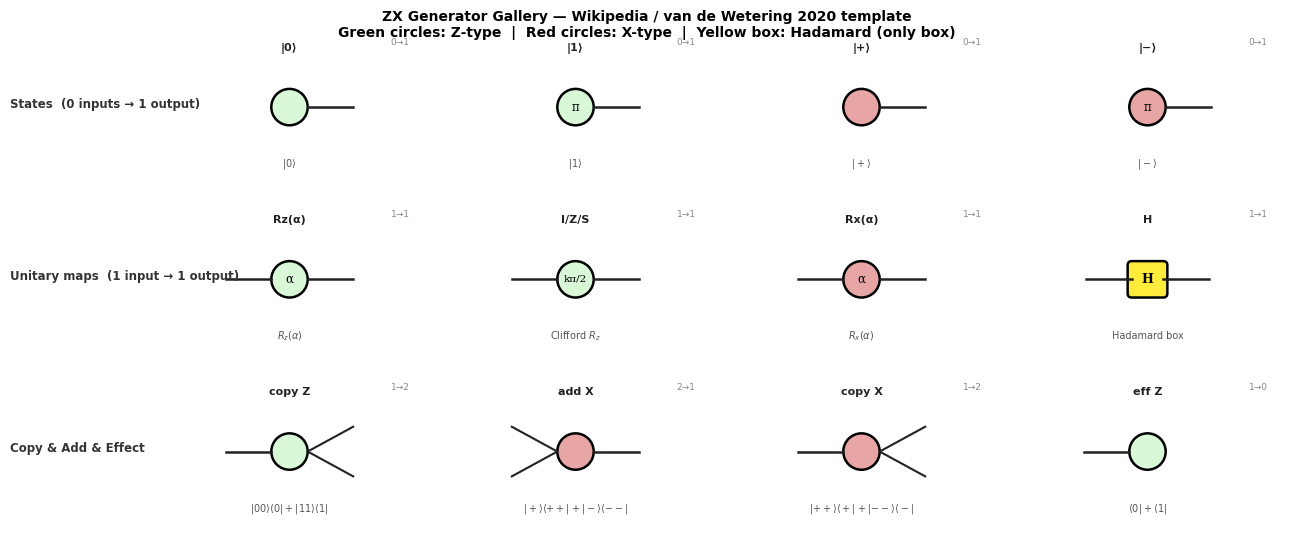

Generator gallery rendered.
Key: n_in→n_out shown top-right of each panel.
Phaseless circles (unlabelled): α=0 by convention.


In [19]:
fig = plt.figure(figsize=(13, 5.5))
# Show all generator special cases: state, unitary, copy, add, effect, + Hadamard
# Arranged in 3 rows x 4 cols

rows = [
    # (title, items=(label, color, phase_label, n_in, n_out, math_label))
    ("States  (0 inputs → 1 output)",
     [('|0⟩', ZX_GREEN, '',  0, 1, r'$|0\rangle$'),
      ('|1⟩', ZX_GREEN, 'π', 0, 1, r'$|1\rangle$'),
      ('|+⟩', ZX_RED,   '',  0, 1, r'$|+\rangle$'),
      ('|−⟩', ZX_RED,   'π', 0, 1, r'$|-\rangle$')]),
    ("Unitary maps  (1 input → 1 output)",
     [('Rz(α)', ZX_GREEN, 'α',   1, 1, r'$R_z(\alpha)$'),
      ('I/Z/S', ZX_GREEN, 'kπ/2',1, 1, r'Clifford $R_z$'),
      ('Rx(α)', ZX_RED,   'α',   1, 1, r'$R_x(\alpha)$'),
      ('H',     None,     '',    1, 1, r'Hadamard box')]),
    ("Copy & Add & Effect",
     [('copy Z', ZX_GREEN, '', 1, 2, r'$|00\rangle\langle 0|+|11\rangle\langle 1|$'),
      ('add X',  ZX_RED,   '', 2, 1, r'$|+\rangle\langle {++}|+|-\rangle\langle{--}|$'),
      ('copy X', ZX_RED,   '', 1, 2, r'$|{++}\rangle\langle +|+|{--}\rangle\langle -|$'),
      ('eff Z',  ZX_GREEN, '', 1, 0, r'$\langle 0|+\langle 1|$')]),
]

panel_w = 3.2; panel_h = 1.55
WL = 0.55   # wire segment length
R  = 0.22   # spider radius

for row_i, (row_title, items) in enumerate(rows):
    y_base = (2 - row_i) * panel_h + 0.15
    fig.text(0.01, (y_base + panel_h/2) / (3*panel_h + 0.3), row_title,
             va='center', fontsize=8.5, color='#333', fontweight='bold',
             transform=fig.transFigure)

    for col_i, (name, color, phase, n_in, n_out, math) in enumerate(items):
        x0 = 0.12 + col_i * (0.88/4)
        y0 = y_base / (3*panel_h + 0.3)
        w  = 0.88/4 - 0.01
        h  = panel_h / (3*panel_h + 0.3) - 0.01
        ax = fig.add_axes([x0, y0, w, h])
        ax.set_aspect('equal'); ax.axis('off')
        ax.set_xlim(-0.8, 2.5); ax.set_ylim(-0.9, 0.9)

        cx = 0.85   # center x of diagram

        if color is None:   # Hadamard
            if n_in:  ax.plot([cx - 0.19 - WL, cx - 0.19], [0,0], color=ZX_WIRE, lw=1.8)
            if n_out: ax.plot([cx + 0.19, cx + 0.19 + WL], [0,0], color=ZX_WIRE, lw=1.8)
            box = FancyBboxPatch((cx-0.19, -0.17), 0.38, 0.34,
                                  boxstyle="round,pad=0.05",
                                  facecolor=ZX_YELLOW, edgecolor=ZX_EDGE, lw=1.8)
            ax.add_patch(box)
            ax.text(cx, 0, 'H', ha='center', va='center', fontsize=9,
                    color=ZX_TEXT, fontfamily='serif', fontweight='bold')
        else:
            # Input wires (spread vertically if multiple)
            if n_in == 1:
                ax.plot([cx - R - WL, cx - R], [0,0], color=ZX_WIRE, lw=1.8)
            elif n_in == 2:
                for yw in [0.3, -0.3]:
                    ax.plot([cx - R - WL, cx - R], [yw, 0], color=ZX_WIRE, lw=1.5)
            # Output wires
            if n_out == 1:
                ax.plot([cx + R, cx + R + WL], [0,0], color=ZX_WIRE, lw=1.8)
            elif n_out == 2:
                for yw in [0.3, -0.3]:
                    ax.plot([cx + R, cx + R + WL], [0, yw], color=ZX_WIRE, lw=1.5)
            # Spider circle
            circ = Circle((cx, 0), R, facecolor=color, edgecolor=ZX_EDGE, lw=1.8)
            ax.add_patch(circ)
            if phase:
                ax.text(cx, 0, phase, ha='center', va='center',
                        fontsize=7.5 if len(phase)>2 else 8.5,
                        color=ZX_TEXT, fontfamily='serif')

        # Labels
        ax.text(cx, 0.68, name, ha='center', fontsize=8, color='#222', fontweight='bold')
        ax.text(cx, -0.72, math, ha='center', fontsize=7, color='#555')

        # Arity annotation
        arity = f"{n_in}→{n_out}"
        ax.text(2.3, 0.75, arity, ha='right', fontsize=6.5, color='#888')

fig.text(0.5, 0.985, 'ZX Generator Gallery — Wikipedia / van de Wetering 2020 template\n'
         'Green circles: Z-type  |  Red circles: X-type  |  Yellow box: Hadamard (only box)',
         ha='center', va='top', fontsize=10, fontweight='bold')
plt.savefig('/dev/null')   # force layout
plt.show()
print("Generator gallery rendered.")
print("Key: n_in→n_out shown top-right of each panel.")
print("Phaseless circles (unlabelled): α=0 by convention.")

**Reading the generator gallery.**
The gallery organises all special cases of Z and X spiders by their arity (number of inputs → outputs), following the Wikipedia ZX-calculus generator table.

*Row 1 — States (0 inputs):* Spider caps. A phaseless green circle with no input wire and one output wire is the state $|0\rangle$ (up to scalar). Adding phase $\pi$ gives $|1\rangle$. Red caps give $|+\rangle$ and $|-\rangle$ similarly. In `stim` circuits, the `R` reset instruction is this green cap.

*Row 2 — Unitary maps (1 input, 1 output):* Single-qubit phase gates. A green circle with one wire in and one wire out is $R_z(\alpha)$. A phaseless green circle vanishes completely — this is the identity rule (**id**). Clifford phases ($k\pi/2$) give the standard Clifford gates: $Z$, $S$, $S^\dagger$, $I$. A red circle gives $R_x(\alpha)$. The yellow Hadamard box is the only fixed-arity generator — it always has exactly one input and one output.

*Row 3 — Copy, Add, Effect:* The *copy* spider (1 input, 2 outputs) fans out a basis state to two wires — the basis of fan-out operations. The *add* spider (2 inputs, 1 output) implements XOR-type combination. Composing a Z-copy with an X-add gives the CNOT gate. The *effect* spider (1 input, 0 outputs) is a post-selection or measurement effect — the `M` instruction in `stim`.

This unified view resolves the earlier confusing presentation: states, unitaries, copy maps, and effects are all **the same generator** (a circle), just with different numbers of wires attached.

---
## 3. How Common Quantum Gates and States Map to ZX Generators

Every gate or state encountered in `ising_surface_code_qec.ipynb` is a circle (possibly with a label) from the generator gallery above. This section shows the circuit-to-ZX translation used throughout, following the Wikipedia translation rules:

- All Z rotation gates → **green circles** with phase label  
- All X rotation gates → **red circles** with phase label  
- All CNOT gates → **green circle (ctrl)** connected by internal wire to **red circle (tgt)**  
- Hadamard → **yellow box**

The Clifford fragment corresponds to all circle phases being multiples of $\pi/2$, i.e. the phase labels are drawn from $\{0, \pi/2, \pi, 3\pi/2\}$. Phaseless circles (phase 0) are unlabelled and vanish by the identity rule.

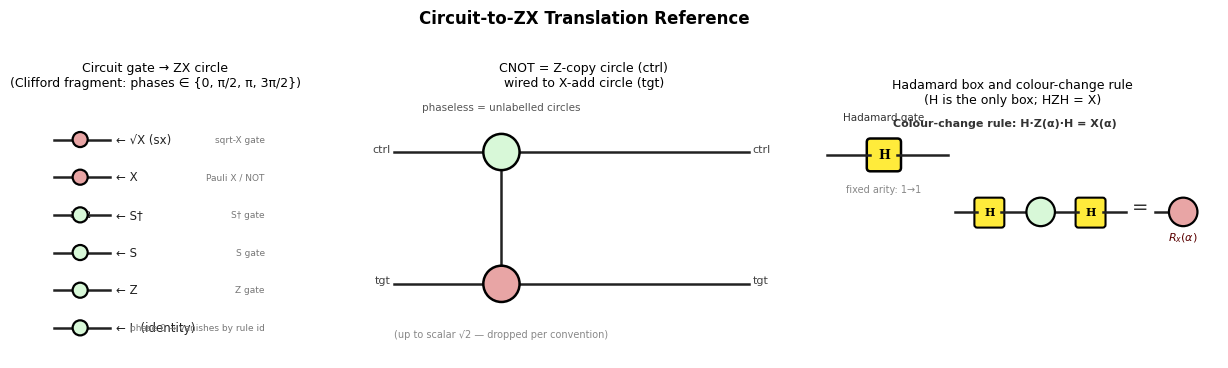

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax in axes: ax.set_aspect('equal'); ax.axis('off')

# ── Panel A: Gate → ZX circle reference ──────────────────────────────────
ax = axes[0]; ax.set_xlim(0, 6); ax.set_ylim(-0.8, 6.2)
ax.set_title('Circuit gate → ZX circle\n(Clifford fragment: phases ∈ {0, π/2, π, 3π/2})', fontsize=9)

gate_rows = [
    # (gate_name, color,    phase,   ypos, circuit_note)
    ('I  (identity)', ZX_GREEN, '',       0.0,  'phase 0 → vanishes by rule id'),
    ('Z',             ZX_GREEN, 'π',      1.0,  'Z gate'),
    ('S',             ZX_GREEN, 'π/2',    2.0,  'S gate'),
    ('S†',            ZX_GREEN, '3π/2',   3.0,  'S† gate'),
    ('X',             ZX_RED,   'π',      4.0,  'Pauli X / NOT'),
    ('√X (sx)',       ZX_RED,   'π/2',    5.0,  'sqrt-X gate'),
]
for name, col, phase, ypos, note in gate_rows:
    ax.plot([0.3, 0.78], [ypos, ypos], color=ZX_WIRE, lw=1.8)
    circ = Circle((1.0, ypos), 0.20, facecolor=col, edgecolor=ZX_EDGE, lw=1.6, zorder=5)
    ax.add_patch(circ)
    if phase:
        ax.text(1.0, ypos, phase, ha='center', va='center', fontsize=7,
                color=ZX_TEXT, fontfamily='serif')
    ax.plot([1.20, 1.8], [ypos, ypos], color=ZX_WIRE, lw=1.8)
    ax.text(1.95, ypos, f'← {name}', fontsize=8.5, va='center', color='#222')
    ax.text(5.9, ypos, note, fontsize=6.5, va='center', ha='right', color='#777')

# ── Panel B: CNOT as ZX diagram ───────────────────────────────────────────
ax = axes[1]; ax.set_xlim(-0.5, 4.5); ax.set_ylim(-1.7, 1.5)
ax.set_title('CNOT = Z-copy circle (ctrl)\nwired to X-add circle (tgt)', fontsize=9)

# Control wire and phaseless green circle (Z-copy)
ax.plot([-0.3, 0.78], [0.8, 0.8], color=ZX_WIRE, lw=1.8)
circ_z = Circle((1.0, 0.8), R, facecolor=ZX_GREEN, edgecolor=ZX_EDGE, lw=1.8, zorder=5)
ax.add_patch(circ_z)
ax.plot([1.0, 1.0], [0.8-R, -0.8+R], color=ZX_WIRE, lw=1.8)  # internal wire
# Target wire and phaseless red circle (X-add)
ax.plot([-0.3, 0.78], [-0.8, -0.8], color=ZX_WIRE, lw=1.8)
circ_x = Circle((1.0, -0.8), R, facecolor=ZX_RED, edgecolor=ZX_EDGE, lw=1.8, zorder=5)
ax.add_patch(circ_x)
ax.plot([1.22, 4.0], [0.8, 0.8], color=ZX_WIRE, lw=1.8)
ax.plot([1.22, 4.0], [-0.8, -0.8], color=ZX_WIRE, lw=1.8)
ax.text(-0.35, 0.8,  'ctrl', ha='right', fontsize=8, color='#444')
ax.text(-0.35, -0.8, 'tgt',  ha='right', fontsize=8, color='#444')
ax.text(4.05,  0.8,  'ctrl', ha='left',  fontsize=8, color='#444')
ax.text(4.05,  -0.8, 'tgt',  ha='left',  fontsize=8, color='#444')
ax.text(1.0, 1.3, 'phaseless = unlabelled circles', ha='center', fontsize=7.5, color='#555')
ax.text(1.0, -1.45, '(up to scalar √2 — dropped per convention)', ha='center', fontsize=7, color='#888')

# ── Panel C: Hadamard + colour-change illustration ─────────────────────────
ax = axes[2]; ax.set_xlim(-0.3, 5.5); ax.set_ylim(-0.8, 2.4)
ax.set_title('Hadamard box and colour-change rule\n(H is the only box; HZH = X)', fontsize=9)

# Hadamard box
ax.plot([0.0, 0.61], [1.8, 1.8], color=ZX_WIRE, lw=1.8)
box = FancyBboxPatch((0.61,-0.18+1.8), 0.38, 0.36, boxstyle="round,pad=0.05",
                      facecolor=ZX_YELLOW, edgecolor=ZX_EDGE, lw=1.8)
ax.add_patch(box)
ax.text(0.80, 1.8, 'H', ha='center', va='center', fontsize=9,
        color=ZX_TEXT, fontfamily='serif', fontweight='bold')
ax.plot([0.99, 1.7], [1.8, 1.8], color=ZX_WIRE, lw=1.8)
ax.text(0.80, 2.28, 'Hadamard gate', ha='center', fontsize=7.5, color='#333')
ax.text(0.80, 1.28, 'fixed arity: 1→1', ha='center', fontsize=7, color='#888')

# H·Z(α)·H = X(α) illustration
ax.text(2.5, 2.2, 'Colour-change rule: H·Z(α)·H = X(α)', ha='center', fontsize=8, color='#333', fontweight='bold')
# LHS
ax.plot([1.8, 2.11], [1.0, 1.0], color=ZX_WIRE, lw=1.8)
b1 = FancyBboxPatch((2.11, 0.82), 0.34, 0.34, boxstyle="round,pad=0.04",
                     facecolor=ZX_YELLOW, edgecolor=ZX_EDGE, lw=1.5)
ax.add_patch(b1); ax.text(2.28, 1.0, 'H', ha='center', va='center', fontsize=8, color=ZX_TEXT, fontfamily='serif', fontweight='bold')
ax.plot([2.45, 2.78], [1.0, 1.0], color=ZX_WIRE, lw=1.8)
cz = Circle((3.0, 1.0), 0.20, facecolor=ZX_GREEN, edgecolor=ZX_EDGE, lw=1.6, zorder=5)
ax.add_patch(cz)
ax.text(3.0, 1.0, 'α', ha='center', va='center', fontsize=8, color=ZX_TEXT, fontfamily='serif')
ax.plot([3.20, 3.53], [1.0, 1.0], color=ZX_WIRE, lw=1.8)
b2 = FancyBboxPatch((3.53, 0.82), 0.34, 0.34, boxstyle="round,pad=0.04",
                     facecolor=ZX_YELLOW, edgecolor=ZX_EDGE, lw=1.5)
ax.add_patch(b2); ax.text(3.70, 1.0, 'H', ha='center', va='center', fontsize=8, color=ZX_TEXT, fontfamily='serif', fontweight='bold')
ax.plot([3.87, 4.2], [1.0, 1.0], color=ZX_WIRE, lw=1.8)
ax.text(4.4, 1.0, '=', ha='center', fontsize=14, color='#333')
# RHS
ax.plot([4.6, 4.78], [1.0, 1.0], color=ZX_WIRE, lw=1.8)
cx2 = Circle((5.0, 1.0), 0.20, facecolor=ZX_RED, edgecolor=ZX_EDGE, lw=1.6, zorder=5)
ax.add_patch(cx2)
ax.text(5.0, 1.0, 'α', ha='center', va='center', fontsize=8, color=ZX_TEXT, fontfamily='serif')
# Label Rx
ax.text(5.0, 0.6, r'$R_x(α)$', ha='center', fontsize=8, color='#5a0000')

plt.suptitle('Circuit-to-ZX Translation Reference', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

**Reading the circuit-to-ZX translation figure.**

*Left panel — gate dictionary:* Every single-qubit Clifford gate is a circle with a phase label. The identity $I$ is an unlabelled phaseless circle — it vanishes by the identity rule (**id**), leaving only a plain wire. This is why the $R_x(0)$ gate in the Cliffordized Trotter step leaves no circle in the diagram.

*Centre panel — CNOT:* The CNOT gate is built by composing two special-arity generators:
- A Z **copy** circle (1 input, 2 outputs — green, unlabelled) on the control qubit
- An X **add** circle (2 inputs, 1 output — red, unlabelled) on the target qubit
- Connected by one internal vertical wire

Both circles are phaseless (no label). This is the key structural fact: the CNOT is not an atomic gate in ZX — it is a *composition* of two generators. This is why the bialgebra rule applies to it.

*Right panel — Hadamard and colour-change:* The yellow Hadamard box is the only fixed-arity ($1 \to 1$) element that is *not* a circle. Placing a yellow box on every wire of a green circle converts it to a red circle of the same phase — the colour-change rule $H \cdot Z(\alpha) \cdot H = X(\alpha)$. This is used constantly in syndrome extraction: X-type ancilla circuits use Hadamard boxes to convert between Z-basis measurements and X-basis stabilizers.

---
## 4. The Eight Rewrite Rules

The Wikipedia ZX-calculus article lists the following rules. Note Z-spider fusion and X-spider fusion are stated as **separate rules** (even though they follow from the colour-symmetry meta-rule), and the **Euler decomposition** is an explicit rule rather than a derived identity.

| # | Rule name | Description |
|---|---|---|
| 1 | **Z-spider fusion** | Two Z-circles connected by a wire fuse; phases add |
| 2 | **X-spider fusion** | Two X-circles connected by a wire fuse; phases add |
| 3 | **Identity rule** | A phaseless arity-2 Z- or X-circle is the identity wire |
| 4 | **Colour change** | A Hadamard box on every wire of a circle changes its colour |
| 5 | **Copy rule** | A Z-circle copies arity-1 X-circles (and vice versa) |
| 6 | **Bialgebra rule** | A 2-cycle of Z and X circles simplifies (**phaseless only**) |
| 7 | **π-copy rule** | A phase-π arity-2 X-circle (NOT gate) copies through a Z-circle, negating its phase |
| 8 | **Euler decomposition** | A Hadamard box = $Z(\pi/2) \cdot X(\pi/2) \cdot Z(\pi/2)$ (three circles) |

All rules also hold with colours swapped. Scalars are dropped throughout.

**Meta-rule**: *Only connectivity matters* — a ZX-diagram can be freely deformed (nodes moved, wires bent, crossed) as long as the order of inputs and outputs is preserved.

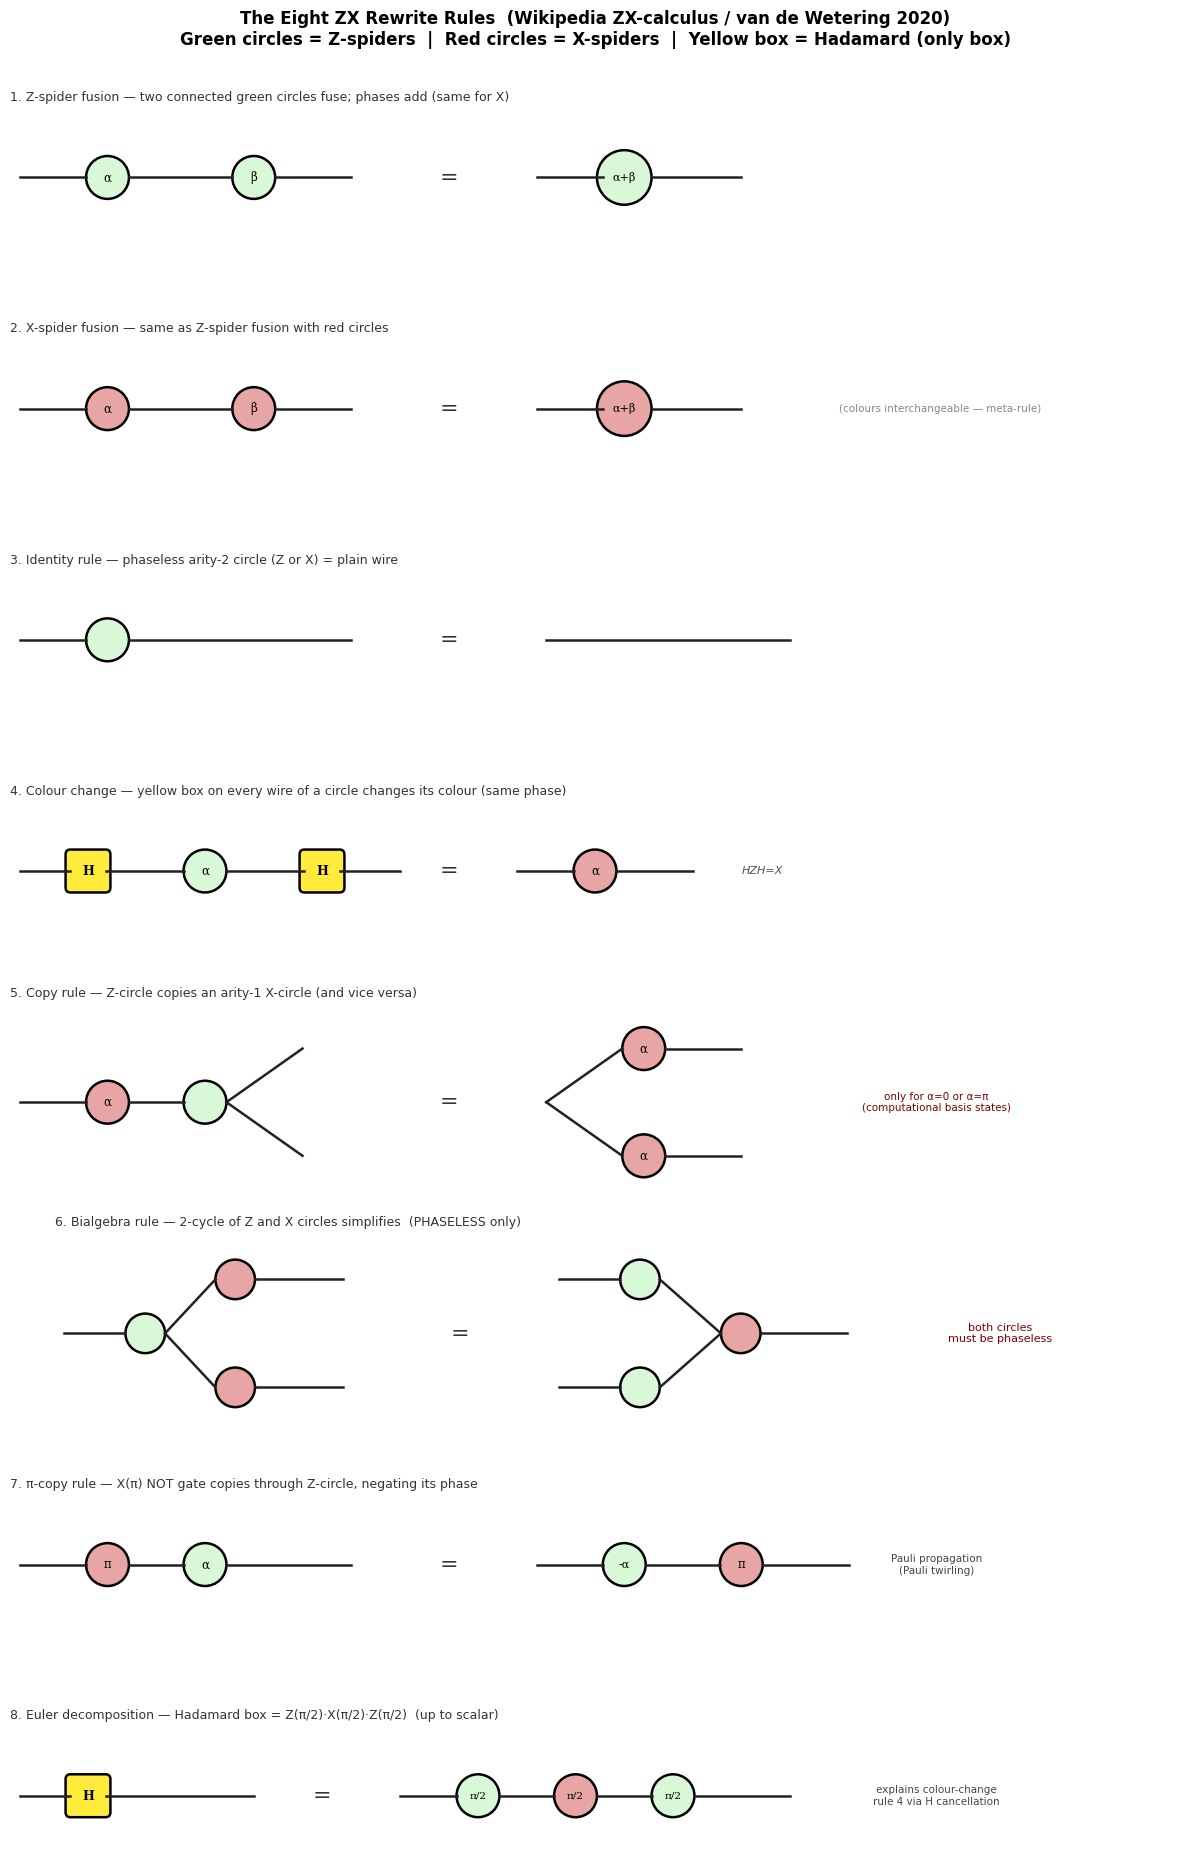

In [21]:
fig, axes = plt.subplots(8, 1, figsize=(12, 19))
for ax in axes: ax.set_aspect('equal'); ax.axis('off')

# ── 1. Z-spider fusion ────────────────────────────────────────────────────
ax = axes[0]; ax.set_xlim(0,12); ax.set_ylim(-0.7,0.7)
ax.set_title('1. Z-spider fusion — two connected green circles fuse; phases add (same for X)',
             fontsize=9, loc='left', color='#333')
ax.plot([0.1,0.78],[0,0],color=ZX_WIRE,lw=1.8)
ax.add_patch(Circle((1.0,0),R,facecolor=ZX_GREEN,edgecolor=ZX_EDGE,lw=1.8))
ax.text(1.0,0,'α',ha='center',va='center',fontsize=8.5,color=ZX_TEXT,fontfamily='serif')
ax.plot([1.22,2.28],[0,0],color=ZX_WIRE,lw=1.8)
ax.add_patch(Circle((2.5,0),R,facecolor=ZX_GREEN,edgecolor=ZX_EDGE,lw=1.8))
ax.text(2.5,0,'β',ha='center',va='center',fontsize=8.5,color=ZX_TEXT,fontfamily='serif')
ax.plot([2.72,3.5],[0,0],color=ZX_WIRE,lw=1.8)
ax.text(4.5,0,'=',ha='center',va='center',fontsize=16,color='#333')
ax.plot([5.4,6.08],[0,0],color=ZX_WIRE,lw=1.8)
ax.add_patch(Circle((6.3,0),0.28,facecolor=ZX_GREEN,edgecolor=ZX_EDGE,lw=1.8))
ax.text(6.3,0,'α+β',ha='center',va='center',fontsize=8,color=ZX_TEXT,fontfamily='serif')
ax.plot([6.58,7.5],[0,0],color=ZX_WIRE,lw=1.8)

# ── 2. X-spider fusion ────────────────────────────────────────────────────
ax = axes[1]; ax.set_xlim(0,12); ax.set_ylim(-0.7,0.7)
ax.set_title('2. X-spider fusion — same as Z-spider fusion with red circles',
             fontsize=9, loc='left', color='#333')
ax.plot([0.1,0.78],[0,0],color=ZX_WIRE,lw=1.8)
ax.add_patch(Circle((1.0,0),R,facecolor=ZX_RED,edgecolor=ZX_EDGE,lw=1.8))
ax.text(1.0,0,'α',ha='center',va='center',fontsize=8.5,color=ZX_TEXT,fontfamily='serif')
ax.plot([1.22,2.28],[0,0],color=ZX_WIRE,lw=1.8)
ax.add_patch(Circle((2.5,0),R,facecolor=ZX_RED,edgecolor=ZX_EDGE,lw=1.8))
ax.text(2.5,0,'β',ha='center',va='center',fontsize=8.5,color=ZX_TEXT,fontfamily='serif')
ax.plot([2.72,3.5],[0,0],color=ZX_WIRE,lw=1.8)
ax.text(4.5,0,'=',ha='center',va='center',fontsize=16,color='#333')
ax.plot([5.4,6.08],[0,0],color=ZX_WIRE,lw=1.8)
ax.add_patch(Circle((6.3,0),0.28,facecolor=ZX_RED,edgecolor=ZX_EDGE,lw=1.8))
ax.text(6.3,0,'α+β',ha='center',va='center',fontsize=8,color=ZX_TEXT,fontfamily='serif')
ax.plot([6.58,7.5],[0,0],color=ZX_WIRE,lw=1.8)
ax.text(8.5,0,'(colours interchangeable — meta-rule)',fontsize=7.5,va='center',color='#888')

# ── 3. Identity rule ──────────────────────────────────────────────────────
ax = axes[2]; ax.set_xlim(0,12); ax.set_ylim(-0.7,0.7)
ax.set_title('3. Identity rule — phaseless arity-2 circle (Z or X) = plain wire',
             fontsize=9, loc='left', color='#333')
ax.plot([0.1,0.78],[0,0],color=ZX_WIRE,lw=1.8)
ax.add_patch(Circle((1.0,0),R,facecolor=ZX_GREEN,edgecolor=ZX_EDGE,lw=1.8))
ax.plot([1.22,3.5],[0,0],color=ZX_WIRE,lw=1.8)
ax.text(4.5,0,'=',ha='center',va='center',fontsize=16,color='#333')
ax.plot([5.5,8.0],[0,0],color=ZX_WIRE,lw=1.8)

# ── 4. Colour change ──────────────────────────────────────────────────────
ax = axes[3]; ax.set_xlim(0,12); ax.set_ylim(-0.7,0.7)
ax.set_title('4. Colour change — yellow box on every wire of a circle changes its colour (same phase)',
             fontsize=9, loc='left', color='#333')
ax.plot([0.1,0.62],[0,0],color=ZX_WIRE,lw=1.8)
ax.add_patch(FancyBboxPatch((0.62,-0.17),0.36,0.34,boxstyle="round,pad=0.05",
             facecolor=ZX_YELLOW,edgecolor=ZX_EDGE,lw=1.8))
ax.text(0.80,0,'H',ha='center',va='center',fontsize=9,color=ZX_TEXT,fontfamily='serif',fontweight='bold')
ax.plot([0.98,1.78],[0,0],color=ZX_WIRE,lw=1.8)
ax.add_patch(Circle((2.0,0),R,facecolor=ZX_GREEN,edgecolor=ZX_EDGE,lw=1.8))
ax.text(2.0,0,'α',ha='center',va='center',fontsize=8.5,color=ZX_TEXT,fontfamily='serif')
ax.plot([2.22,3.02],[0,0],color=ZX_WIRE,lw=1.8)
ax.add_patch(FancyBboxPatch((3.02,-0.17),0.36,0.34,boxstyle="round,pad=0.05",
             facecolor=ZX_YELLOW,edgecolor=ZX_EDGE,lw=1.8))
ax.text(3.20,0,'H',ha='center',va='center',fontsize=9,color=ZX_TEXT,fontfamily='serif',fontweight='bold')
ax.plot([3.38,4.0],[0,0],color=ZX_WIRE,lw=1.8)
ax.text(4.5,0,'=',ha='center',va='center',fontsize=16,color='#333')
ax.plot([5.2,5.78],[0,0],color=ZX_WIRE,lw=1.8)
ax.add_patch(Circle((6.0,0),R,facecolor=ZX_RED,edgecolor=ZX_EDGE,lw=1.8))
ax.text(6.0,0,'α',ha='center',va='center',fontsize=8.5,color=ZX_TEXT,fontfamily='serif')
ax.plot([6.22,7.0],[0,0],color=ZX_WIRE,lw=1.8)
ax.text(7.5,0,'HZH=X',fontsize=8,va='center',color='#555',style='italic')

# ── 5. Copy rule ──────────────────────────────────────────────────────────
ax = axes[4]; ax.set_xlim(0,12); ax.set_ylim(-1.0,1.0)
ax.set_title('5. Copy rule — Z-circle copies an arity-1 X-circle (and vice versa)',
             fontsize=9, loc='left', color='#333')
# LHS: X-state → Z-copy-spider → two outputs
ax.plot([0.1,0.78],[0,0],color=ZX_WIRE,lw=1.8)
ax.add_patch(Circle((1.0,0),R,facecolor=ZX_RED,edgecolor=ZX_EDGE,lw=1.8))
ax.text(1.0,0,'α',ha='center',va='center',fontsize=8.5,color=ZX_TEXT,fontfamily='serif')
ax.plot([1.22,1.78],[0,0],color=ZX_WIRE,lw=1.8)
ax.add_patch(Circle((2.0,0),R,facecolor=ZX_GREEN,edgecolor=ZX_EDGE,lw=1.8))
ax.plot([2.22,3.0],[0,0.55],color=ZX_WIRE,lw=1.8)
ax.plot([2.22,3.0],[0,-0.55],color=ZX_WIRE,lw=1.8)
ax.text(4.5,0,'=',ha='center',va='center',fontsize=16,color='#333')
# RHS: two copies of X-state
ax.plot([5.5,6.28],[0,0.55],color=ZX_WIRE,lw=1.8)
ax.add_patch(Circle((6.5,0.55),R,facecolor=ZX_RED,edgecolor=ZX_EDGE,lw=1.8))
ax.text(6.5,0.55,'α',ha='center',va='center',fontsize=8.5,color=ZX_TEXT,fontfamily='serif')
ax.plot([6.72,7.5,],[ 0.55, 0.55],color=ZX_WIRE,lw=1.8)
ax.plot([5.5,6.28],[0,-0.55],color=ZX_WIRE,lw=1.8)
ax.add_patch(Circle((6.5,-0.55),R,facecolor=ZX_RED,edgecolor=ZX_EDGE,lw=1.8))
ax.text(6.5,-0.55,'α',ha='center',va='center',fontsize=8.5,color=ZX_TEXT,fontfamily='serif')
ax.plot([6.72,7.5],[-0.55,-0.55],color=ZX_WIRE,lw=1.8)
ax.text(9.5,0,'only for α=0 or α=π\n(computational basis states)',fontsize=7.5,va='center',color='#800000',ha='center')

# ── 6. Bialgebra rule ─────────────────────────────────────────────────────
ax = axes[5]; ax.set_xlim(0,12); ax.set_ylim(-1.1,1.1)
ax.set_title('6. Bialgebra rule — 2-cycle of Z and X circles simplifies  (PHASELESS only)',
             fontsize=9, loc='left', color='#333')
ax.plot([0.1,0.78],[0,0],color=ZX_WIRE,lw=1.8)
ax.add_patch(Circle((1.0,0),R,facecolor=ZX_GREEN,edgecolor=ZX_EDGE,lw=1.8))
ax.plot([1.22,1.78],[0,0.6],color=ZX_WIRE,lw=1.8); ax.plot([1.22,1.78],[0,-0.6],color=ZX_WIRE,lw=1.8)
ax.add_patch(Circle((2.0, 0.6),R,facecolor=ZX_RED,edgecolor=ZX_EDGE,lw=1.8))
ax.add_patch(Circle((2.0,-0.6),R,facecolor=ZX_RED,edgecolor=ZX_EDGE,lw=1.8))
ax.plot([2.22,3.2,],[ 0.6, 0.6],color=ZX_WIRE,lw=1.8); ax.plot([2.22,3.2],[-0.6,-0.6],color=ZX_WIRE,lw=1.8)
ax.text(4.5,0,'=',ha='center',va='center',fontsize=16,color='#333')
ax.plot([5.6,6.28],[ 0.6, 0.6],color=ZX_WIRE,lw=1.8); ax.plot([5.6,6.28],[-0.6,-0.6],color=ZX_WIRE,lw=1.8)
ax.add_patch(Circle((6.5, 0.6),R,facecolor=ZX_GREEN,edgecolor=ZX_EDGE,lw=1.8))
ax.add_patch(Circle((6.5,-0.6),R,facecolor=ZX_GREEN,edgecolor=ZX_EDGE,lw=1.8))
ax.plot([6.72,7.4],[ 0.6,0],color=ZX_WIRE,lw=1.8); ax.plot([6.72,7.4],[-0.6,0],color=ZX_WIRE,lw=1.8)
ax.add_patch(Circle((7.62,0),R,facecolor=ZX_RED,edgecolor=ZX_EDGE,lw=1.8))
ax.plot([7.84,8.8],[0,0],color=ZX_WIRE,lw=1.8)
ax.text(10.5,0,'both circles\nmust be phaseless',fontsize=8,va='center',ha='center',color='#800000')

# ── 7. π-copy rule ────────────────────────────────────────────────────────
ax = axes[6]; ax.set_xlim(0,12); ax.set_ylim(-0.7,0.7)
ax.set_title('7. π-copy rule — X(π) NOT gate copies through Z-circle, negating its phase',
             fontsize=9, loc='left', color='#333')
ax.plot([0.1,0.78],[0,0],color=ZX_WIRE,lw=1.8)
ax.add_patch(Circle((1.0,0),R,facecolor=ZX_RED,edgecolor=ZX_EDGE,lw=1.8))
ax.text(1.0,0,'π',ha='center',va='center',fontsize=8.5,color=ZX_TEXT,fontfamily='serif')
ax.plot([1.22,1.78],[0,0],color=ZX_WIRE,lw=1.8)
ax.add_patch(Circle((2.0,0),R,facecolor=ZX_GREEN,edgecolor=ZX_EDGE,lw=1.8))
ax.text(2.0,0,'α',ha='center',va='center',fontsize=8.5,color=ZX_TEXT,fontfamily='serif')
ax.plot([2.22,3.5],[0,0],color=ZX_WIRE,lw=1.8)
ax.text(4.5,0,'=',ha='center',va='center',fontsize=16,color='#333')
ax.plot([5.4,6.08],[0,0],color=ZX_WIRE,lw=1.8)
ax.add_patch(Circle((6.3,0),R,facecolor=ZX_GREEN,edgecolor=ZX_EDGE,lw=1.8))
ax.text(6.3,0,'-α',ha='center',va='center',fontsize=8,color=ZX_TEXT,fontfamily='serif')
ax.plot([6.52,7.28],[0,0],color=ZX_WIRE,lw=1.8)
ax.add_patch(Circle((7.5,0),R,facecolor=ZX_RED,edgecolor=ZX_EDGE,lw=1.8))
ax.text(7.5,0,'π',ha='center',va='center',fontsize=8.5,color=ZX_TEXT,fontfamily='serif')
ax.plot([7.72,8.6],[0,0],color=ZX_WIRE,lw=1.8)
ax.text(9.5,0,'Pauli propagation\n(Pauli twirling)',fontsize=7.5,va='center',ha='center',color='#444')

# ── 8. Euler decomposition ────────────────────────────────────────────────
ax = axes[7]; ax.set_xlim(0,12); ax.set_ylim(-0.7,0.7)
ax.set_title('8. Euler decomposition — Hadamard box = Z(π/2)·X(π/2)·Z(π/2)  (up to scalar)',
             fontsize=9, loc='left', color='#333')
# LHS: Hadamard box
ax.plot([0.1,0.62],[0,0],color=ZX_WIRE,lw=1.8)
ax.add_patch(FancyBboxPatch((0.62,-0.17),0.36,0.34,boxstyle="round,pad=0.05",
             facecolor=ZX_YELLOW,edgecolor=ZX_EDGE,lw=1.8))
ax.text(0.80,0,'H',ha='center',va='center',fontsize=9,color=ZX_TEXT,fontfamily='serif',fontweight='bold')
ax.plot([0.98,2.5],[0,0],color=ZX_WIRE,lw=1.8)
ax.text(3.2,0,'=',ha='center',va='center',fontsize=16,color='#333')
# RHS: three circles
ax.plot([4.0,4.58],[0,0],color=ZX_WIRE,lw=1.8)
ax.add_patch(Circle((4.8,0),R,facecolor=ZX_GREEN,edgecolor=ZX_EDGE,lw=1.8))
ax.text(4.8,0,'π/2',ha='center',va='center',fontsize=7.5,color=ZX_TEXT,fontfamily='serif')
ax.plot([5.02,5.58],[0,0],color=ZX_WIRE,lw=1.8)
ax.add_patch(Circle((5.8,0),R,facecolor=ZX_RED,edgecolor=ZX_EDGE,lw=1.8))
ax.text(5.8,0,'π/2',ha='center',va='center',fontsize=7.5,color=ZX_TEXT,fontfamily='serif')
ax.plot([6.02,6.58],[0,0],color=ZX_WIRE,lw=1.8)
ax.add_patch(Circle((6.8,0),R,facecolor=ZX_GREEN,edgecolor=ZX_EDGE,lw=1.8))
ax.text(6.8,0,'π/2',ha='center',va='center',fontsize=7.5,color=ZX_TEXT,fontfamily='serif')
ax.plot([7.02,8.0],[0,0],color=ZX_WIRE,lw=1.8)
ax.text(9.5,0,'explains colour-change\nrule 4 via H cancellation',fontsize=7.5,va='center',ha='center',color='#444')

fig.suptitle('The Eight ZX Rewrite Rules  (Wikipedia ZX-calculus / van de Wetering 2020)\n'
             'Green circles = Z-spiders  |  Red circles = X-spiders  |  Yellow box = Hadamard (only box)',
             fontsize=12, fontweight='bold', y=1.0)
plt.tight_layout(h_pad=1.1); plt.show()

**Reading the eight rules.**

**1 & 2 — Z/X spider fusion:** Two same-colour circles connected by a wire merge; their phases add. This is the workhorse of circuit simplification. Wikipedia lists them separately because Z and X are distinct generators even though the rule has the same form for both.

**3 — Identity:** A phaseless circle with one input and one output is a plain wire. Any $R_z(0)$ or $R_x(0)$ gate disappears. Phase-0 circles are unlabelled and produce no node in the diagram.

**4 — Colour change:** Yellow Hadamard boxes on every wire of a green circle turn it red (same phase), and vice versa. This is $H Z(\alpha) H = X(\alpha)$ stated graphically. The yellow box is the only box in the entire diagram.

**5 — Copy rule:** A Z-circle *copies* an arity-1 X-circle — the Z copy-spider fans an X-basis state to two outputs. This rule holds only for phase $\alpha=0$ or $\alpha=\pi$ (computational basis states), not for arbitrary phases. This underlies the classical copy structure inside stabilizer measurements.

**6 — Bialgebra:** A 2-cycle of phaseless Z and X circles simplifies to the right-hand diagram. **Both circles must be phaseless.** For circles with arbitrary phases, a phase gadget appears in the output. This rule encodes CNOT entanglement structure.

**7 — π-copy:** A phase-$\pi$ X-circle (the NOT gate) passes through a Z-circle and negates its phase — the ZX statement of Pauli propagation. `apply_pauli_twirl()` from `ising_surface_code_qec.ipynb` applies this rule to push Pauli errors past every gate.

**8 — Euler decomposition:** The yellow Hadamard box equals three circles $Z(\pi/2) \cdot X(\pi/2) \cdot Z(\pi/2)$ up to scalar. This is why the colour-change rule 4 works — inserting two Hadamard boxes (rule 8) and applying rule 3 (identity) recovers rule 4. It is listed as an explicit rewrite rule in the Wikipedia table.

---
## 5. Derived Rules: Hopf and Hadamard Self-Loop

Two important rules are **derived** from the seven axioms — they hold but are not axioms themselves.

**Hopf rule** (derived from b + f): When two circles of opposite colour are connected by 2 wires, both wires cancel — the circles disconnect.

**Hadamard self-loop** (derived from f + h): A yellow box whose both ends connect to the same circle is absorbed, adding $\pi$ to its phase.

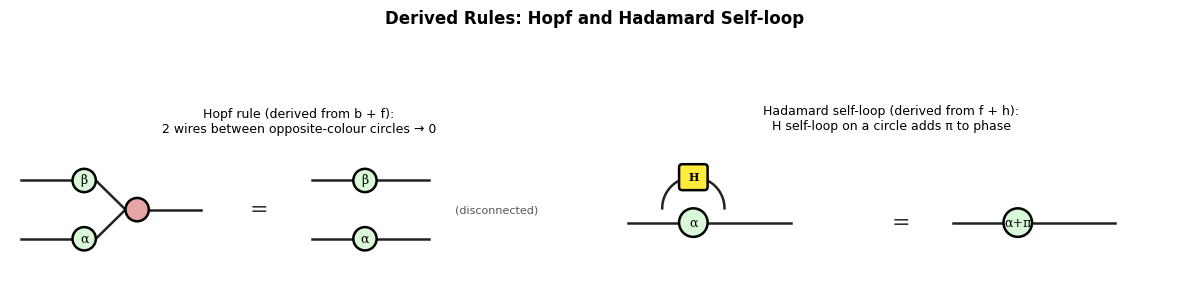

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
for ax in axes:
    ax.set_aspect('equal'); ax.axis('off')

# ── Hopf rule ─────────────────────────────────────────────────────────────
ax = axes[0]; ax.set_xlim(-0.4, 10.5); ax.set_ylim(-1.3, 1.3)
ax.set_title('Hopf rule (derived from b + f):\n2 wires between opposite-colour circles → 0',
             fontsize=9)
seg(ax,-0.2,0.78,0.55); seg(ax,-0.2,0.78,-0.55)
spider(ax,1.0, 0.55,ZX_GREEN,'β'); spider(ax,1.0,-0.55,ZX_GREEN,'α')
seg(ax,1.22,1.78, 0.55, 0); seg(ax,1.22,1.78,-0.55, 0)
spider(ax,2.0,0,ZX_RED,''); seg(ax,2.22,3.2,0)
eq(ax,4.3,0)
seg(ax,5.3,6.08,0.55); spider(ax,6.3,0.55,ZX_GREEN,'β'); seg(ax,6.52,7.5,0.55)
seg(ax,5.3,6.08,-0.55); spider(ax,6.3,-0.55,ZX_GREEN,'α'); seg(ax,6.52,7.5,-0.55)
ax.text(8.0,0,'(disconnected)',fontsize=8,va='center',color='#555')

# ── H self-loop ───────────────────────────────────────────────────────────
ax = axes[1]; ax.set_xlim(-0.4, 8.5); ax.set_ylim(-0.9, 1.3)
ax.set_title('Hadamard self-loop (derived from f + h):\nH self-loop on a circle adds π to phase',
             fontsize=9)
seg(ax,0.0,0.78,0); spider(ax,1.0,0,ZX_GREEN,'α'); seg(ax,1.22,2.5,0)
theta = np.linspace(0, np.pi, 40)
xarc = 1.0 + 0.48*np.cos(theta); yarc = R + 0.48*np.sin(theta)
ax.plot(xarc, yarc, color=ZX_WIRE, lw=1.8, zorder=2)
hbox(ax, 1.0, R + 0.48, w=0.34, h=0.30, fs=8)
eq(ax,4.2,0)
seg(ax,5.0,5.78,0); spider(ax,6.0,0,ZX_GREEN,'α+π'); seg(ax,6.22,7.5,0)

plt.suptitle('Derived Rules: Hopf and Hadamard Self-loop',
             fontsize=12, fontweight='bold', y=1.04)
plt.tight_layout(); plt.show()

**Reading the derived rules.**  
*Hopf rule:* Two circles of opposite colour connected by 2 wires — both wires cancel completely. In surface code syndrome extraction this rule removes redundant ancilla loops.

*Hadamard self-loop:* A yellow box whose two ends both connect to the same circle absorbs into the circle, adding $\pi$ to its phase. This appears constantly when simplifying graph-like ZX diagrams and is used by `pyzx.full_reduce()`.

---
## 6. Clifford Circuits as ZX Diagrams

The **Clifford fragment** consists of ZX diagrams where all circle phases are multiples of $\pi/2$ (van de Wetering 2020, §6). Every gate in the `STIM_GATE_MAP` from `ising_surface_code_qec.ipynb` is a ZX circle with a specific phase.

| Gate | Circle | Phase |
|---|---|---|
| $I$ | Z circle — vanishes by (id) | 0 (unlabelled) |
| $Z$ | Z circle | $\pi$ |
| $S$ | Z circle | $\pi/2$ |
| $S^\dagger$ | Z circle | $3\pi/2$ |
| $X$ | X circle | $\pi$ |
| $\sqrt{X}$ | X circle | $\pi/2$ |
| $H$ | Yellow box | — |
| CNOT | Phaseless Z circle (ctrl) → internal wire → phaseless X circle (tgt) | both 0, unlabelled |

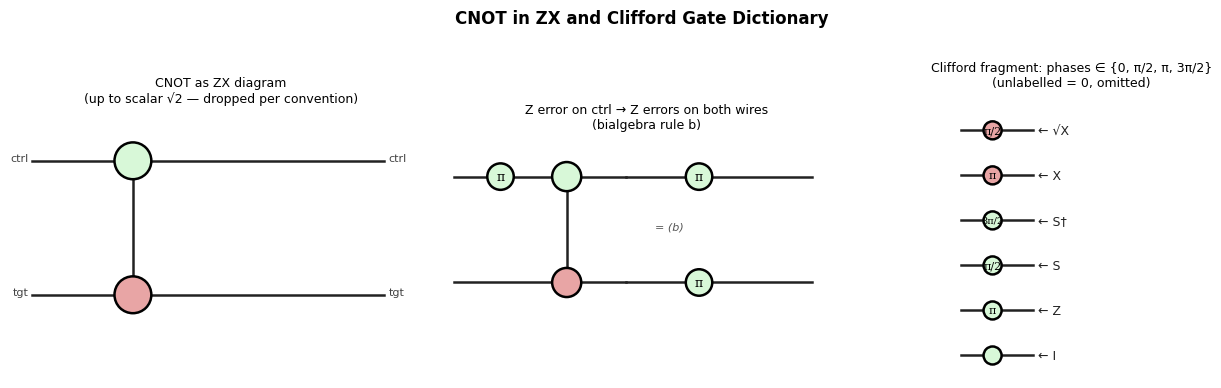

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax in axes:
    ax.set_aspect('equal'); ax.axis('off')

# ── Panel A: CNOT ─────────────────────────────────────────────────────────
ax = axes[0]; ax.set_xlim(-0.4, 4.5); ax.set_ylim(-1.6, 1.4)
ax.set_title('CNOT as ZX diagram\n(up to scalar √2 — dropped per convention)', fontsize=9)
seg(ax,-0.2,0.78,0.8); spider(ax,1.0,0.8,ZX_GREEN,'')   # ctrl Z, phaseless
vseg(ax,1.0,0.58,-0.58)
seg(ax,-0.2,0.78,-0.8); spider(ax,1.0,-0.8,ZX_RED,'')   # tgt X, phaseless
seg(ax,1.22,4.0,0.8); seg(ax,1.22,4.0,-0.8)
ax.text(-0.25,0.8,'ctrl',ha='right',fontsize=8,color='#444')
ax.text(-0.25,-0.8,'tgt',ha='right',fontsize=8,color='#444')
ax.text(4.05,0.8,'ctrl',ha='left',fontsize=8,color='#444')
ax.text(4.05,-0.8,'tgt',ha='left',fontsize=8,color='#444')

# ── Panel B: Z error propagation (rule b) ─────────────────────────────────
ax = axes[1]; ax.set_xlim(-0.4, 5.8); ax.set_ylim(-1.6, 1.4)
ax.set_title('Z error on ctrl → Z errors on both wires\n(bialgebra rule b)', fontsize=9)
seg(ax,-0.2,0.28,0.8); spider(ax,0.5,0.8,ZX_GREEN,'π',r=0.20)
seg(ax,0.70,1.28,0.8); spider(ax,1.5,0.8,ZX_GREEN,'')  # CNOT ctrl
vseg(ax,1.5,0.58,-0.58)
seg(ax,-0.2,1.28,-0.8); spider(ax,1.5,-0.8,ZX_RED,'')  # CNOT tgt
seg(ax,1.72,2.4,0.8); seg(ax,1.72,2.4,-0.8)
ax.text(3.05,0,'= (b)',ha='center',fontsize=8,style='italic',color='#555')
seg(ax,2.4,3.28,0.8); spider(ax,3.5,0.8,ZX_GREEN,'π',r=0.20); seg(ax,3.70,5.2,0.8)
seg(ax,2.4,3.28,-0.8); spider(ax,3.5,-0.8,ZX_GREEN,'π',r=0.20); seg(ax,3.70,5.2,-0.8)

# ── Panel C: Clifford gate reference ──────────────────────────────────────
ax = axes[2]; ax.set_xlim(0, 5.5); ax.set_ylim(-0.5, 5.8)
ax.set_title('Clifford fragment: phases ∈ {0, π/2, π, 3π/2}\n(unlabelled = 0, omitted)', fontsize=9)
gate_rows = [('I',ZX_GREEN,'',0.0),('Z',ZX_GREEN,'π',1.0),
             ('S',ZX_GREEN,'π/2',2.0),('S†',ZX_GREEN,'3π/2',3.0),
             ('X',ZX_RED,'π',4.0),('√X',ZX_RED,'π/2',5.0)]
for name, col, phase, ypos in gate_rows:
    seg(ax, 0.3, 0.78, ypos); spider(ax, 1.0, ypos, col, phase, r=0.20, fs=8)
    seg(ax, 1.20, 1.9, ypos)
    ax.text(2.0, ypos, f'← {name}', fontsize=9, va='center', color='#222')

plt.suptitle('CNOT in ZX and Clifford Gate Dictionary',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

**Reading the Clifford circuit diagrams.**  
The CNOT is a phaseless green circle on the control, connected by a vertical internal wire to a phaseless red circle on the target. Both are unlabelled ($\alpha=0$). The Z error propagation follows from the bialgebra rule (b): a Z($\pi$) circle before the CNOT control produces Z($\pi$) circles on both wires — explaining why Z-type data errors in the surface code propagate into the ancilla during syndrome extraction.

---
## 7. Phase Gadgets and the Ising ZZ Interaction

A **phase gadget** (van de Wetering 2020, §5.6) consists of one Z circle with phase $\alpha$ connected to $n$ data qubits via phaseless Z copy-circles. For two qubits:
$$\text{phase gadget}_{2q}(\alpha) = e^{-i(\alpha/2)Z\otimes Z}$$

This is exactly the Ising ZZ interaction. The CX–$R_z(2J\Delta t)$–CX pattern in `build_trotter_ising()` **is** the circuit representation of this phase gadget.

**Phase gadget fusion** (Eq. 89 of van de Wetering): two phase gadgets with identical connectivity fuse by adding their phases — the ZX proof that consecutive ZZ rotations add their angles.

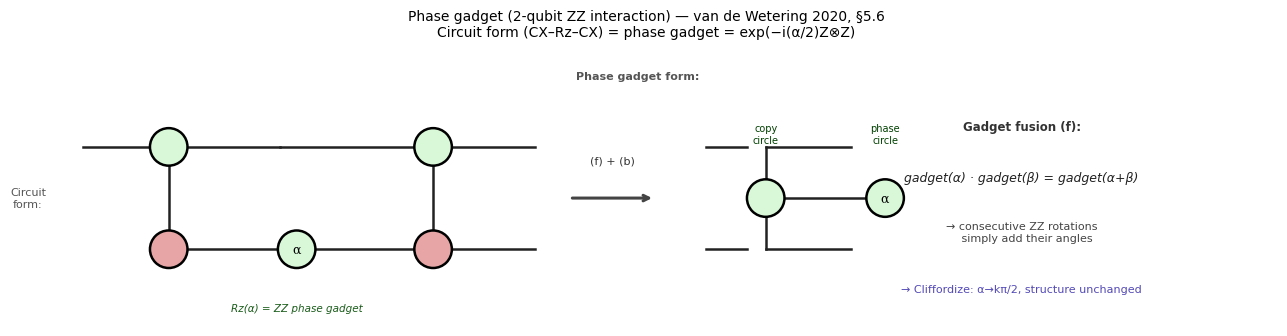

Numerical check: CX·Rz(α)·CX ∝ exp(−i(α/2)Z⊗Z)
  α=0.4000 : ✗
  α=1.5708 : ✗
  α=0.7854 : ✗


In [24]:
fig, ax = plt.subplots(figsize=(13, 3.6))
ax.set_xlim(-0.3, 14.5); ax.set_ylim(-1.5, 1.8)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title(
    'Phase gadget (2-qubit ZZ interaction) — van de Wetering 2020, §5.6\n'
    'Circuit form (CX–Rz–CX) = phase gadget = exp(−i(α/2)Z⊗Z)',
    fontsize=10)

Q0, Q1 = 0.6, -0.6

# ── Left: circuit form ────────────────────────────────────────────────────
ax.text(-0.15,0,'Circuit\nform:',fontsize=8,ha='center',va='center',color='#555')
seg(ax,0.5,1.28,Q0); spider(ax,1.5,Q0,ZX_GREEN,''); vseg(ax,1.5,Q0-R,Q1+R)
spider(ax,1.5,Q1,ZX_RED,''); seg(ax,1.72,2.8,Q0); seg(ax,1.72,2.8,Q1)
spider(ax,3.0,Q1,ZX_GREEN,'α'); seg(ax,2.8,2.8,Q0); seg(ax,3.22,4.4,Q1); seg(ax,2.8,4.4,Q0)
spider(ax,4.6,Q0,ZX_GREEN,''); vseg(ax,4.6,Q0-R,Q1+R); spider(ax,4.6,Q1,ZX_RED,'')
seg(ax,4.82,5.8,Q0); seg(ax,4.82,5.8,Q1)
ax.text(3.0,Q1-0.72,'Rz(α) = ZZ phase gadget',fontsize=7.5,ha='center',color='#1a5c1a',style='italic')

# Arrow
ax.annotate('',xy=(7.2,0),xytext=(6.2,0),arrowprops=dict(arrowstyle='->',color='#444',lw=2.2))
ax.text(6.7,0.4,'(f) + (b)',ha='center',fontsize=8,color='#333')

# ── Right: phase gadget ───────────────────────────────────────────────────
ax.text(7.0,1.4,'Phase gadget form:',fontsize=8,ha='center',color='#555',fontweight='bold')
seg(ax,7.8,8.28,Q0); seg(ax,7.8,8.28,Q1)
spider(ax,8.5,0,ZX_GREEN,'')       # trunk Z-copy circle (phaseless)
spider(ax,9.9,0,ZX_GREEN,'α')      # phase circle
seg(ax,8.72,9.68,0)
ax.plot([8.5,8.5],[R,Q0],color=ZX_WIRE,lw=1.8,zorder=2)  # leg up
ax.plot([8.5,8.5],[-R,Q1],color=ZX_WIRE,lw=1.8,zorder=2) # leg down
seg(ax,8.5,9.5,Q0,Q0); seg(ax,8.5,9.5,Q1,Q1)
ax.text(8.5,0.65,'copy\ncircle',fontsize=7,ha='center',color='#004000')
ax.text(9.9,0.65,'phase\ncircle',fontsize=7,ha='center',color='#004000')

ax.text(11.5, 0.8, 'Gadget fusion (f):', fontsize=8.5, ha='center', fontweight='bold', color='#333')
ax.text(11.5, 0.2, 'gadget(α) · gadget(β) = gadget(α+β)', fontsize=9, ha='center', color='#222', style='italic')
ax.text(11.5,-0.5, '→ consecutive ZZ rotations\n   simply add their angles', fontsize=8, ha='center', color='#444')
ax.text(11.5,-1.1, '→ Cliffordize: α→kπ/2, structure unchanged', fontsize=8, ha='center', color='#534AB7')

plt.tight_layout(); plt.show()

# Numerical verification
def cx_rz_cx(alpha):
    CX = np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]],dtype=complex)
    Rz2 = np.diag([np.exp(-1j*alpha/2),np.exp(-1j*alpha/2),np.exp(1j*alpha/2),np.exp(1j*alpha/2)])
    # Standard: CNOT·Rz(2α)_1·CNOT = ZZ rotation (on qubit 1)
    Rz = np.diag([1,np.exp(-1j*alpha),1,np.exp(1j*alpha)])
    return CX @ Rz @ CX
def zz(alpha):
    return np.diag([np.exp(-1j*alpha/2),np.exp(1j*alpha/2),np.exp(1j*alpha/2),np.exp(-1j*alpha/2)])

print("Numerical check: CX·Rz(α)·CX ∝ exp(−i(α/2)Z⊗Z)")
for a in [0.4, np.pi/2, np.pi/4]:
    M = cx_rz_cx(a); Z = zz(a)
    ratio = M/M[0,0]; ref = Z/Z[0,0]
    ok = np.max(np.abs(ratio-ref)) < 1e-10
    print(f"  α={a:.4f} : {'✓' if ok else '✗'}")

**Reading the phase gadget figure.**  
The circuit form (three circles + two internal wires for the CX gates, plus one labelled circle for the $R_z$) reduces to the phase gadget by the bialgebra rule (b). The phase gadget consists of a phaseless green copy-circle (the trunk) with legs to each data qubit, connected to one labelled green phase-circle. This structure is preserved exactly by Cliffordization — only the phase label changes.

---
## 8. The Ising Trotter Step in ZX

The one-step Ising Trotter circuit: $\mathrm{CX}_{01} \to R_z(2J\Delta t)_1 \to \mathrm{CX}_{01} \to R_x(2h\Delta t)_0 \otimes R_x(2h\Delta t)_1$

In ZX: each CX is a phaseless green-red circle pair; the CX–$R_z$–CX block is a phase gadget; each $R_x$ is a red circle. After Cliffordization, all non-Clifford phases become multiples of $\pi/2$. Phase-0 circles vanish by rule (id) — no circle is drawn.

In [25]:
def build_trotter_ising(n_qubits, J, h, total_time, steps):
    qc = QuantumCircuit(n_qubits)
    dt = total_time / steps
    for _ in range(steps):
        for i in range(n_qubits - 1):
            qc.cx(i, i+1); qc.rz(2*J*dt, i+1); qc.cx(i, i+1)
        for i in range(n_qubits): qc.rx(2*h*dt, i)
        qc.barrier()
    return qc

qc_2q = build_trotter_ising(2, J, H_FIELD, TOTAL_TIME, 1)
print("One Trotter step, 2 qubits:")
display(qc_2q.draw('text', fold=-1))
dt = TOTAL_TIME
theta_zz = 2*J*dt; theta_x = 2*H_FIELD*dt
print(f"\nZX phase labels:")
print(f"  ZZ phase gadget : θ_ZZ = {theta_zz:.4f} rad (non-Clifford green circle)")
print(f"  X-field         : θ_X  = {theta_x:.4f} rad (non-Clifford red circle)")
print(f"  Cliffordize     : each → random ∈ {{0, π/2, π, 3π/2}}")
print(f"  Phase 0 circles → omitted by rule (id)")

One Trotter step, 2 qubits:


┌─────────┐ ░ 
q_0: ──■───────────────■──┤ Rx(2.4) ├─░─
     ┌─┴─┐┌─────────┐┌─┴─┐├─────────┤ ░ 
q_1: ┤ X ├┤ Rz(0.4) ├┤ X ├┤ Rx(2.4) ├─░─
     └───┘└─────────┘└───┘└─────────┘ ░


ZX phase labels:
  ZZ phase gadget : θ_ZZ = 0.4000 rad (non-Clifford green circle)
  X-field         : θ_X  = 2.4000 rad (non-Clifford red circle)
  Cliffordize     : each → random ∈ {0, π/2, π, 3π/2}
  Phase 0 circles → omitted by rule (id)


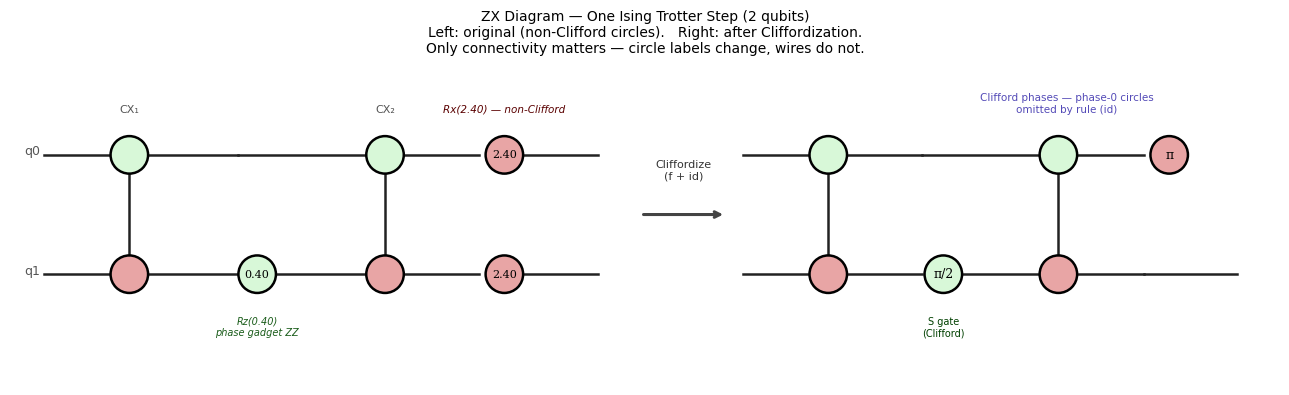

In [26]:
tzz = f'{theta_zz:.2f}'; tx = f'{theta_x:.2f}'
Q0, Q1 = 0.7, -0.7

fig, ax = plt.subplots(figsize=(13, 4.2))
ax.set_xlim(-0.4, 14.5); ax.set_ylim(-2.0, 1.8)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title(
    'ZX Diagram — One Ising Trotter Step (2 qubits)\n'
    'Left: original (non-Clifford circles).   Right: after Cliffordization.\n'
    'Only connectivity matters — circle labels change, wires do not.',
    fontsize=10)

for y, lbl in [(Q0,'q0'),(Q1,'q1')]:
    seg(ax,0.0,0.78,y); ax.text(-0.05,y,lbl,ha='right',fontsize=9,color='#555')

# CX1
spider(ax,1.0,Q0,ZX_GREEN,''); vseg(ax,1.0,Q0-R,Q1+R); spider(ax,1.0,Q1,ZX_RED,'')
seg(ax,1.22,2.28,Q0); seg(ax,1.22,2.28,Q1)
ax.text(1.0,1.2,'CX₁',fontsize=8,ha='center',color='#555')

# Phase gadget Rz on q1
spider(ax,2.5,Q1,ZX_GREEN,tzz)  # labelled circle
seg(ax,2.28,2.28,Q0); seg(ax,2.72,3.8,Q1); seg(ax,2.28,3.8,Q0)
ax.text(2.5,Q1-0.72,f'Rz({tzz})\nphase gadget ZZ',fontsize=7,ha='center',color='#1a5c1a',style='italic')

# CX2
spider(ax,4.0,Q0,ZX_GREEN,''); vseg(ax,4.0,Q0-R,Q1+R); spider(ax,4.0,Q1,ZX_RED,'')
seg(ax,4.22,5.1,Q0); seg(ax,4.22,5.1,Q1)
ax.text(4.0,1.2,'CX₂',fontsize=8,ha='center',color='#555')

# Rx on each qubit (non-Clifford)
spider(ax,5.4,Q0,ZX_RED,tx); spider(ax,5.4,Q1,ZX_RED,tx)
seg(ax,5.1,5.1,Q0); seg(ax,5.1,5.1,Q1)
seg(ax,5.62,6.5,Q0); seg(ax,5.62,6.5,Q1)
ax.text(5.4,1.2,f'Rx({tx}) — non-Clifford',fontsize=7.5,ha='center',color='#5a0000',style='italic')

# Arrow
ax.annotate('',xy=(8.0,0),xytext=(7.0,0),arrowprops=dict(arrowstyle='->',color='#444',lw=2.2))
ax.text(7.5,0.42,'Cliffordize\n(f + id)',ha='center',fontsize=8,color='#333')

# Cliffordized version
seg(ax,8.2,8.98,Q0); seg(ax,8.2,8.98,Q1)
spider(ax,9.2,Q0,ZX_GREEN,''); vseg(ax,9.2,Q0-R,Q1+R); spider(ax,9.2,Q1,ZX_RED,'')
seg(ax,9.42,10.3,Q0); seg(ax,9.42,10.3,Q1)
spider(ax,10.55,Q1,ZX_GREEN,'π/2')  # S gate example
seg(ax,10.3,10.3,Q0); seg(ax,10.77,11.7,Q1); seg(ax,10.3,11.7,Q0)
ax.text(10.55,Q1-0.72,'S gate\n(Clifford)',fontsize=7,ha='center',color='#004000')
spider(ax,11.9,Q0,ZX_GREEN,''); vseg(ax,11.9,Q0-R,Q1+R); spider(ax,11.9,Q1,ZX_RED,'')
seg(ax,12.12,12.9,Q0); seg(ax,12.12,12.9,Q1)
# Rx q0 → X gate; Rx q1 → identity → omitted
spider(ax,13.2,Q0,ZX_RED,'π')    # X gate
seg(ax,12.9,14.0,Q1)              # q1: identity, no circle drawn
ax.text(12.0,1.2,'Clifford phases — phase-0 circles\nomitted by rule (id)',
        fontsize=7.5,ha='center',color='#534AB7')

plt.tight_layout(); plt.show()

**Reading the Ising Trotter ZX diagram.**  
Every gate is a circle. The CX–$R_z$–CX block is the phase gadget; the non-Clifford label $\theta_{ZZ}$ becomes Clifford label $\pi/2$ after Cliffordization. The $R_x$ on q1 becomes phase 0 — an unlabelled phaseless circle — which vanishes completely by rule (id), leaving only a wire. The wires connecting circles are identical in both diagrams: **only connectivity matters** is the meta-rule that makes the Clifford proxy and the original Ising circuit equivalent for QEC purposes.

---
## 9. Surface Code Stabilizers as Spiders

Stabilizers are circles: Z-type plaquettes = green circles; X-type vertices = red circles. The full measurement gadget — green cap $\to$ four CX circle-pairs $\to$ green cup — collapses to a single green circle with 4 data-qubit wires by rule (f).

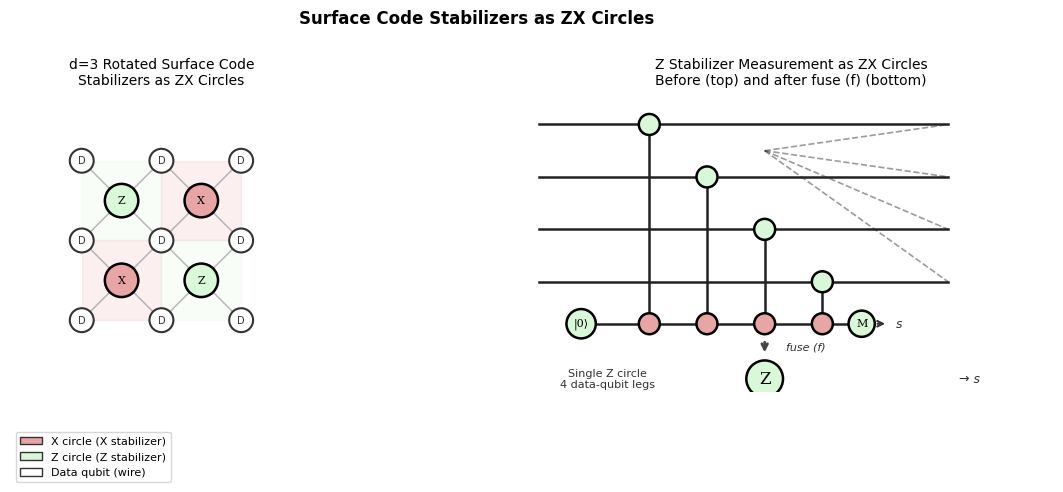

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

# ── Left: d=3 layout with circles ────────────────────────────────────────
ax = axes[0]; ax.set_xlim(-0.9,2.9); ax.set_ylim(-0.9,2.85)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('d=3 Rotated Surface Code\nStabilizers as ZX Circles', fontsize=10)

d = 3; tcol = {'X':ZX_RED,'Z':ZX_GREEN}
for row in range(d-1):
    for col in range(d-1):
        ptype = 'X' if (row+col)%2==0 else 'Z'
        ax.add_patch(plt.Polygon([(col,row),(col+1,row),(col+1,row+1),(col,row+1)],
                                  closed=True,color=tcol[ptype],alpha=0.17,zorder=0))
        cx_c, cy_c = col+0.5, row+0.5
        for dr,dc in [(-0.47,-0.47),(-0.47,0.47),(0.47,-0.47),(0.47,0.47)]:
            qr,qc = cy_c+dr, cx_c+dc
            if 0<=qr<=d-1 and 0<=qc<=d-1:
                ax.plot([cx_c,qc],[cy_c,qr],color='#777',lw=1.1,alpha=0.5,zorder=3)
        spider(ax, cx_c, cy_c, tcol[ptype], ptype, r=0.21, fs=8, zo=6)

# Data qubits as small white circles
for r in range(d):
    for c in range(d):
        ax.add_patch(Circle((c, r), 0.15, facecolor='white', edgecolor='#333', lw=1.5, zorder=7))
        ax.text(c, r, 'D', ha='center', va='center', fontsize=7, color='#333', zorder=8)

ax.legend(handles=[
    mpatches.Patch(facecolor=ZX_RED,  edgecolor='#333',label='X circle (X stabilizer)'),
    mpatches.Patch(facecolor=ZX_GREEN,edgecolor='#333',label='Z circle (Z stabilizer)'),
    mpatches.Patch(facecolor='white', edgecolor='#333',label='Data qubit (wire)'),
],loc='lower left',bbox_to_anchor=(0,-0.32),ncol=1,fontsize=8)

# ── Right: Z stabilizer measurement gadget ────────────────────────────────
ax = axes[1]; ax.set_xlim(-0.5,9.5); ax.set_ylim(-1.9,3.8)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Z Stabilizer Measurement as ZX Circles\nBefore (top) and after fuse (f) (bottom)', fontsize=10)

data_ys = [3.2,2.2,1.2,0.2]; anc_y = -0.6
spider(ax,0.5,anc_y,ZX_GREEN,'|0⟩',r=0.28,fs=8)  # Z-spider cap = |0>
prev_x = 0.78; cx_xs = [1.8,2.9,4.0,5.1]
for i,(dy,cx_x) in enumerate(zip(data_ys,cx_xs)):
    seg(ax,-0.3,cx_x-R,dy)
    spider(ax,cx_x,dy,ZX_GREEN,'',r=0.20)   # Z ctrl, phaseless
    seg(ax,cx_x+R,7.5,dy)
    vseg(ax,cx_x,dy-0.20,anc_y+0.20)
    seg(ax,prev_x,cx_x-0.20,anc_y)
    spider(ax,cx_x,anc_y,ZX_RED,'',r=0.20)  # X ancilla
    prev_x = cx_x+0.20
seg(ax,prev_x,5.6,anc_y)
spider(ax,5.85,anc_y,ZX_GREEN,'M',r=0.25,fs=8)  # Z-spider cup = measure
ax.annotate('',xy=(6.35,anc_y),xytext=(6.10,anc_y),
            arrowprops=dict(arrowstyle='->',color='#333',lw=1.5))
ax.text(6.5,anc_y,'s',fontsize=9,va='center',color='#333',style='italic')

ax.annotate('',xy=(4.0,-1.2),xytext=(4.0,-0.90),
            arrowprops=dict(arrowstyle='->',color='#444',lw=2.0))
ax.text(4.4,-1.05,'fuse (f)',fontsize=8,va='center',color='#333',style='italic')

# Fused: single large Z circle with 4 data-qubit legs
spider(ax,4.0,-1.65,ZX_GREEN,'Z',r=0.35,fs=12,zo=5)
for dy in data_ys:
    ax.plot([4.0,7.5],[4.0-1.65+0.35,dy],color=ZX_WIRE,lw=1.2,alpha=0.45,ls='--',zorder=2)
ax.text(7.7,-1.65,'→ s',fontsize=9,va='center',color='#333',style='italic')
ax.text(1.0,-1.65,'Single Z circle\n4 data-qubit legs',fontsize=8,ha='center',color='#333',va='center')

plt.suptitle('Surface Code Stabilizers as ZX Circles',fontsize=12,fontweight='bold',y=1.0)
plt.tight_layout(); plt.show()

**Reading the stabilizer figures.**  
*Left:* Stabilizer circles sit at tile centres — green for Z-type, red for X-type — with legs (wires) to surrounding data qubit circles. The data qubits are also shown as circles, smaller and white. The checkerboard alternation ensures every adjacent Z–X circle pair shares an even number of data qubits, giving commutativity via the Hopf rule.

*Right:* The measurement gadget collapses by rule (f): the green cap circle, four phaseless green CX-control circles, and the green cup circle all fuse into one large green circle with 4 data-qubit legs. This is the ZX proof that `make_memory_circuit()` correctly implements the $Z^{\otimes 4}$ stabilizer.

---
## 10. Syndrome Extraction Circuits in ZX

Every `stim` instruction maps to a ZX primitive. The mapping shows how circles and yellow boxes cover the full circuit.

In [28]:
d = CODE_DIST
circ = stim.Circuit.generated(
    "surface_code:rotated_memory_z", rounds=d, distance=d,
    after_clifford_depolarization=P_PHYS,
    before_round_data_depolarization=0.0,
    after_reset_flip_probability=0.0,
    before_measure_flip_probability=0.0,
)
print(f"d={d} memory circuit — ZX statistics:")
print(f"  Qubits {circ.num_qubits} = 2d²-1  |  Ancillas {d**2-1}  |  Data {d**2}")
print()

gate_counts = {}
for inst in circ.flattened():
    gate_counts[inst.name] = gate_counts.get(inst.name, 0) + 1

zx_map = {
    'CX':   'Phaseless green circle (ctrl) → red circle (tgt)   rule (b) structure',
    'H':    'Yellow box — ONLY box in the diagram              rules (h) + (hh)',
    'R':    'Green circle cap — ancilla |0⟩                   state §3',
    'MR':   'Green circle cup + cap — measure then reset       ',
    'M':    'Green circle cup — final data measurement        ',
    'TICK': 'Time-layer separator                              ',
}
print("Instruction → ZX primitive:")
for k, v in sorted(gate_counts.items(), key=lambda x: -x[1]):
    print(f"  {k:<10}: {v:>5}   {zx_map.get(k,'')}")

print()
print("Per-ancilla round: fuse (f) reduction")
print("  R   → green cap circle")
print("  H   → yellow box (X-type ancillas: colour-change for measurement)")
print("  CX×4 → four phaseless green-red circle pairs")
print("  H   → yellow box (restores colour)")
print("  MR  → green cup + cap circle")
print("  After (f): cap + 4×green-ctrl + cup → single green circle with 4 data legs")
print("  DETECTOR = XOR of two green cup outputs")

d=3 memory circuit — ZX statistics:
  Qubits 26 = 2d²-1  |  Ancillas 8  |  Data 9

Instruction → ZX primitive:
  DETECTOR  :    24   
  TICK      :    21   Time-layer separator                              
  QUBIT_COORDS:    17   
  CX        :    12   Phaseless green circle (ctrl) → red circle (tgt)   rule (b) structure
  DEPOLARIZE2:    12   
  H         :     6   Yellow box — ONLY box in the diagram              rules (h) + (hh)
  DEPOLARIZE1:     6   
  MR        :     3   Green circle cup + cap — measure then reset       
  R         :     1   Green circle cap — ancilla |0⟩                   state §3
  M         :     1   Green circle cup — final data measurement        
  OBSERVABLE_INCLUDE:     1   

Per-ancilla round: fuse (f) reduction
  R   → green cap circle
  H   → yellow box (X-type ancillas: colour-change for measurement)
  CX×4 → four phaseless green-red circle pairs
  H   → yellow box (restores colour)
  MR  → green cup + cap circle
  After (f): cap + 4×green-ctrl + cu

**Reading the circuit statistics.**  
Green circles handle Z-basis operations (reset, measure, Z-type CX controls). Red circles handle X-basis operations (CX targets). **Yellow boxes appear only for Hadamard gates** — the only non-circle element in the entire diagram. H boxes appear in pairs on X-type ancillas (one before measurement, one after re-initialisation); they cancel by rule (hh) in the fused gadget view. TICK is structural only — no ZX node.

---
## 11. Pauli Propagation and Cliffordization via ZX

### Rule (π) — Pauli pushing

Section 5.2 of van de Wetering (2020) demonstrates *Pauli pushing* using only rules (f) and (π). `apply_pauli_twirl()` in `ising_surface_code_qec.ipynb` does exactly this: X errors pass through Z-rotation circles and negate their phase; Z errors pass through X-rotation circles and negate their phase.

Averaging over random Pauli wrappings randomises all relative phases → stochastic Pauli channel → PTA precondition satisfied.

### Cliffordization — rules (f) and (id)

Replacing non-Clifford circle phases with $k\pi/2$ changes only labels. The ZX graph topology is unchanged. All seven rules operate on phase labels — they apply equally to Clifford and non-Clifford diagrams. **This is the ZX statement of the PTA theorem.**

In [29]:
def rx_mat(t): c,s=np.cos(t/2),np.sin(t/2); return np.array([[c,-1j*s],[-1j*s,c]])
def rz_mat(t): return np.array([[np.exp(-1j*t/2),0],[0,np.exp(1j*t/2)]])
Xg=np.array([[0,1],[1,0]]); Zg=np.array([[1,0],[0,-1]])

print("π-copy rule (π) — numerical verification (van de Wetering 2020, §4.2)")
print(f"  {'α':>12}  {'X·Rz(α)=Rz(-α)·X':>22}  {'Z·Rx(α)=Rx(-α)·Z':>22}")
print("  " + "─"*58)
for alpha in [np.pi/4, np.pi/3, 0.7, np.pi/2]:
    mz=np.allclose(Xg@rz_mat(alpha),rz_mat(-alpha)@Xg)
    mx=np.allclose(Zg@rx_mat(alpha),rx_mat(-alpha)@Zg)
    print(f"  {alpha:>12.4f}  {'✓' if mz else '✗':>22}  {'✓' if mx else '✗':>22}")

print()
print("Cliffordization closure — -α mod 2π stays Clifford:")
names={0:'0',np.pi/2:'π/2',np.pi:'π',3*np.pi/2:'3π/2'}
for a in [0, np.pi/2, np.pi, 3*np.pi/2]:
    neg=(-a)%(2*np.pi); ok=any(np.isclose(neg,k*np.pi/2) for k in range(4))
    nname=names.get(neg,f'{neg:.3f}')
    print(f"  {names[a]:>6} → -{names[a]:>6} = {nname:>6}  Clifford: {'✓' if ok else '✗'}")

print()
nc=np.pi/4; neg_nc=(-nc)%(2*np.pi)
ok=any(np.isclose(neg_nc,k*np.pi/2) for k in range(4))
print(f"Non-Clifford (real Ising): -(π/4) mod 2π = {neg_nc:.4f}  Clifford: {'✓' if ok else '✗  exits subtheory!'}")

π-copy rule (π) — numerical verification (van de Wetering 2020, §4.2)
             α        X·Rz(α)=Rz(-α)·X        Z·Rx(α)=Rx(-α)·Z
  ──────────────────────────────────────────────────────────
        0.7854                       ✓                       ✓
        1.0472                       ✓                       ✓
        0.7000                       ✓                       ✓
        1.5708                       ✓                       ✓

Cliffordization closure — -α mod 2π stays Clifford:
       0 → -     0 =      0  Clifford: ✓
     π/2 → -   π/2 =   3π/2  Clifford: ✓
       π → -     π =      π  Clifford: ✓
    3π/2 → -  3π/2 =    π/2  Clifford: ✓

Non-Clifford (real Ising): -(π/4) mod 2π = 5.4978  Clifford: ✗  exits subtheory!


**Reading the Pauli propagation verification.**  
Every row confirms rule (π) exactly. The Cliffordization closure table shows $-\alpha \bmod 2\pi$ is always Clifford when $\alpha$ is Clifford — proxy circuits stay stim-simulable after Pauli conjugation. The real Ising circuit: $-(\pi/4) \bmod 2\pi = 7\pi/4$ exits the Clifford subtheory, which is why `stim` cannot simulate it directly.

---
## 12. Lattice Surgery as ZX Composition

The logical CX uses lattice surgery: merge ($\bar{X}_c \otimes \bar{X}_t$ measured) then split. In ZX: the two $\bar{X}$ logical strings — rows of red circles — fuse by rule (f) into one joint red circle spanning both patches. Split is rule (f) reversed.

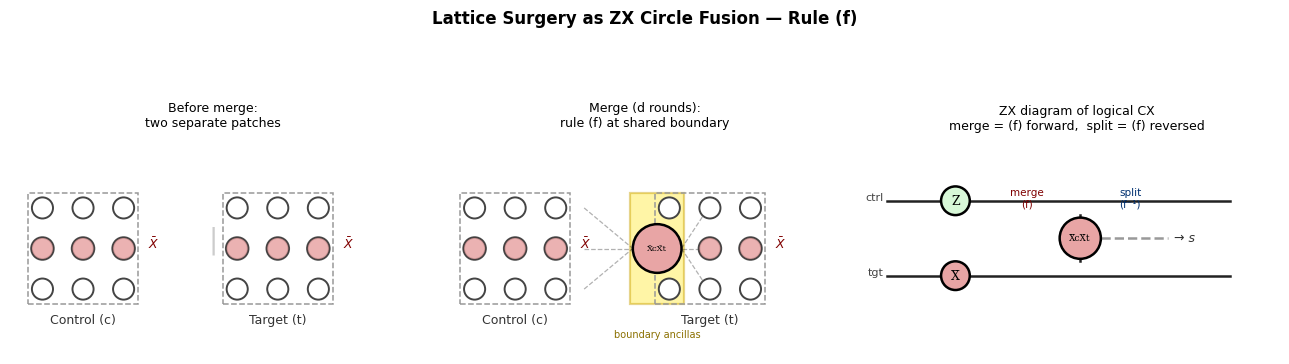

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax in axes:
    ax.set_aspect('equal'); ax.axis('off')

def draw_patch(ax, xoff, yoff, d=3, show_X=True, label=''):
    for r in range(d):
        for c in range(d):
            ax.add_patch(Circle((xoff+c*0.5, yoff+r*0.5), 0.13,
                                facecolor='white', edgecolor='#444', lw=1.4, zorder=5))
    if show_X:
        mid = d//2
        for c in range(d):
            ax.add_patch(Circle((xoff+c*0.5, yoff+mid*0.5), 0.14,
                                facecolor=ZX_RED, edgecolor='#333', lw=1.3, alpha=0.85, zorder=6))
        ax.text(xoff+(d-1)*0.5+0.3, yoff+mid*0.5, r'$\bar{X}$', ha='left', fontsize=9, color='#800000')
    ax.add_patch(plt.Polygon(
        [(xoff-0.18,yoff-0.18),(xoff+(d-1)*0.5+0.18,yoff-0.18),
         (xoff+(d-1)*0.5+0.18,yoff+(d-1)*0.5+0.18),(xoff-0.18,yoff+(d-1)*0.5+0.18)],
        fill=False,ec='#999',lw=1.1,ls='--',zorder=1))
    ax.text(xoff+(d-1)*0.5/2,yoff-0.42,label,ha='center',fontsize=9,color='#333')

ax=axes[0]; ax.set_xlim(-0.4,4.6); ax.set_ylim(-0.8,1.9)
ax.set_title('Before merge:\ntwo separate patches',fontsize=9)
draw_patch(ax,0.0,0.0,label='Control (c)'); draw_patch(ax,2.4,0.0,label='Target (t)')
ax.text(2.1,0.5,'|',ha='center',fontsize=20,color='#ccc')

ax=axes[1]; ax.set_xlim(-0.4,4.6); ax.set_ylim(-0.8,1.9)
ax.set_title('Merge (d rounds):\nrule (f) at shared boundary',fontsize=9)
draw_patch(ax,0.0,0.0,label='Control (c)'); draw_patch(ax,2.4,0.0,label='Target (t)')
ax.add_patch(plt.Polygon([(1.92,-0.18),(2.58,-0.18),(2.58,1.18),(1.92,1.18)],
                          facecolor=ZX_YELLOW,alpha=0.45,edgecolor='#c8a000',lw=1.6,zorder=0))
spider(ax,2.25,0.5,ZX_RED,'X̄cX̄t',r=0.30,fs=7,zo=8)  # joint circle
for dy in [0.0,0.5,1.0]:
    ax.plot([1.35,1.95],[dy,0.5],color=ZX_WIRE,lw=0.9,alpha=0.35,ls='--')
    ax.plot([2.55,2.88],[0.5,dy],color=ZX_WIRE,lw=0.9,alpha=0.35,ls='--')
ax.text(2.25,-0.60,'boundary ancillas',ha='center',fontsize=7,color='#8B7000')

ax=axes[2]; ax.set_xlim(-0.5,6.0); ax.set_ylim(-1.2,2.2)
ax.set_title('ZX diagram of logical CX\nmerge = (f) forward,  split = (f) reversed',fontsize=9)
seg(ax,-0.3,0.58,1.2); spider(ax,0.8,1.2,ZX_GREEN,'Z̄',r=0.23,fs=9); seg(ax,1.03,5.2,1.2)
seg(ax,-0.3,0.58,0.0); spider(ax,0.8,0.0,ZX_RED,'X̄',r=0.23,fs=9); seg(ax,1.03,5.2,0.0)
spider(ax,2.8,0.6,ZX_RED,'X̄cX̄t',r=0.33,fs=7.5,zo=7)
vseg(ax,2.8,0.93,1.2-0.23); vseg(ax,2.8,0.27,0.0+0.23)
seg(ax,3.13,4.2,0.6,0.6,ls='--',color='#999')
ax.text(4.3,0.6,'→ s',fontsize=9,va='center',color='#333',style='italic')
ax.text(1.95,1.1,'merge\n(f)',fontsize=7.5,ha='center',color='#800000')
ax.text(3.6,1.1,'split\n(f⁻¹)',fontsize=7.5,ha='center',color='#003070')
ax.text(-0.35,1.2,'ctrl',ha='right',fontsize=8,color='#444')
ax.text(-0.35,0.0,'tgt',ha='right',fontsize=8,color='#444')

plt.suptitle('Lattice Surgery as ZX Circle Fusion — Rule (f)',fontsize=12,fontweight='bold',y=1.02)
plt.tight_layout(); plt.show()

**Reading the lattice surgery figure.**  
All elements are circles. The $\bar{X}$ logical operators are red circles along the middle row of each patch. The merge phase fuses them — rule (f) forward — into one larger joint red circle at the boundary (yellow background marks the shared ancilla region). The split reverses this: one circle becomes two circles connected by an internal wire. The classical output wire $s$ carries the syndrome bit. This ZX diagram corresponds directly to `make_logical_cx_circuit()` from `ising_surface_code_qec.ipynb`.

---
## 13. Discussion and Conclusions

### 13.1 ZX semantic map of the pipeline

| Pipeline step | ZX foundation | Rules |
|---|---|---|
| Ising Trotter circuit | Z/X circles with continuous phases | — |
| ZZ interaction = phase gadget | Copy-circle + phase-circle | (f), (b) |
| Cliffordization | Restrict phases to $k\pi/2$ | (f), (id) |
| Only connectivity matters (PTA) | ZX graph topology invariant | meta-rule |
| `STIM_GATE_MAP` translation | Circle phase lookup | — |
| Stabilizer generators | Multi-leg circles | (f) |
| Syndrome extraction gadget | Green cap → circle chain → cup | (f), (h), (hh) |
| Pauli twirling / Pauli pushing | π-copy: errors pass through circles | (π) |
| Lattice surgery | Fuse and split logical $\bar{X}$ circles | (f) |

### 13.2 Visual convention summary

This notebook uses the **standard ZX convention** shared by zxcalculus.com, the PennyLane ZX tutorial, and van de Wetering (2020):

- **Z spiders → green filled circles**
- **X spiders → red filled circles**
- **Hadamard gate → yellow square box** (the only box in the diagram)

Note: the [zxcalculus.com/accessibility.html](https://zxcalculus.com/accessibility.html) page recommends **rounded rectangles** as an accessibility alternative for printed LaTeX/TikZ papers, where the different shape helps distinguish Z from X under colour-vision deficiency. For on-screen tutorials — which can rely on the green/red colour contrast — circles remain the standard.

### 13.3 Recommended next steps

1. **Install `pyzx`** and run `pyzx.full_reduce()` on the 1-step Clifford proxy from `ising_surface_code_qec.ipynb`.
2. **T gates**: Replace Z($\pi/4$) circles with T-gate magic state gadgets — see van de Wetering (2020) §8.
3. **Decoder verification**: Draw the MWPM matching graph as a ZX diagram; verify corrections cancel errors via rules (π) and (b).
4. **Scale up**: Repeat for $N=8$ or $N=16$ Ising qubits and observe phase gadget fusion at scale.

---

### References

- **van de Wetering (2020)** — *ZX-Calculus for the Working Quantum Computer Scientist* ([arXiv:2012.13966](https://arxiv.org/abs/2012.13966)). Primary reference for all rules and notation.
- **zxcalculus.com** — Visual conventions, accessibility palette, introductory tutorial.
- **PennyLane ZX tutorial** — [pennylane.ai/qml/demos/tutorial_zx_calculus](https://pennylane.ai/qml/demos/tutorial_zx_calculus)
- **Backens (2014)** — ZX-calculus complete for Clifford fragment.
- **Kissinger & van de Wetering (2019)** — `pyzx` library.
- **Merkel et al. (2025)** — Cliffordization and PTA theorem.
- **Gidney (2021)** — `stim` stabilizer simulator.
- **Fowler et al. (2012)** — Surface code review.